In [1]:
 #*******************************************************************************************
 #
 #  File Name:  econ_anlys_gnc.ipynb
 #
 #  File Description:
 #      This interactive Python notebook, econ_anlys_gnc.ipynb, analyzes the relationship 
 #      between an x-series and five y-series.
 #      
 #
 #  Date            Description                             Programmer
 #  ----------      ------------------------------------    ------------------
 #  04/10/2026      Initial Development                     Nicholas J. George
 #
 #******************************************************************************************/

import dtypesx
import econ_anlys_vrb
import logx
import mathx
import matplotlibx
import pandasx
import warnings

import numpy  as np
import pandas as pd

warnings.filterwarnings('ignore')

In [2]:
econ_anlys_vrb.setup \
    (xcml        = True, 
     x           = 'covid_c&d', 
     y           = 'metals', 
     tm_prd      = 'recovery', 
     x_roll      = True,
     x_roll_days = 7,
     xpct        = True,
     ypct        = True,
     bse         = 'econ_anlys')

XCOL, XSBJ, XCAT, XLBL, XTTL, RLL, DY, XPCT = econ_anlys_vrb.get_xattr()

YCOL, YSBJ, YCAT, YLBL, YTTL, YPCT          = econ_anlys_vrb.get_yattr()

PRD, ST, ED                                 = econ_anlys_vrb.get_prd_attr()

DSG                                         = econ_anlys_vrb.get_dsg()

Y                                           = econ_anlys_vrb.get_y_enum()

In [3]:
CONSTANT_LOCAL_FILE_NAME = DSG + '.ipynb'

In [4]:
logx.set_log_mode(True)

logx.set_image_mode(True)


logx.begin_program(DSG)

Program execution has begun...



# <br> **Part 1: X-Variable Analysis**

## **Subsection 1.1: Full Period (01/22/2020 — 09/14/2022)**

## **1.1.1: Extract Data from Files**

### **X-Variable**

In [5]:
x_df = pd.read_json(econ_anlys_vrb.crn_dict['file']['x'], typ = 'frame')

logx.log_write_obj(x_df)

In [6]:
x_series = x_df[XCOL][ST:ED]

x_series = dtypesx.rtn_date_idxs(x_series)


if RLL:  x_series = x_series.rolling(window = DY).mean()

if XPCT: x_series = dtypesx.cnv_to_pct_chg(x_series)


logx.log_write_obj(x_series)

### **Y-Variables**

In [7]:
y_df = pd.read_json(econ_anlys_vrb.crn_dict['file']['y'], typ = 'frame')

logx.log_write_obj(y_df)

In [8]:
y1_series = y_df[YCAT[Y.Y1.value]][ST:ED]

y1_series = dtypesx.rtn_date_idxs(y1_series)


if YPCT: y1_series = dtypesx.cnv_to_pct_chg(y1_series)


logx.log_write_obj(y1_series)

In [9]:
y2_series = y_df[YCAT[Y.Y2.value]][ST:ED]

y2_series = dtypesx.rtn_date_idxs(y2_series)


if YPCT: y2_series = dtypesx.cnv_to_pct_chg(y2_series)
    

logx.log_write_obj(y2_series)

In [10]:
y3_series = y_df[YCAT[Y.Y3.value]][ST:ED]

y3_series = dtypesx.rtn_date_idxs(y3_series)


if YPCT: y3_series = dtypesx.cnv_to_pct_chg(y3_series)
    

logx.log_write_obj(y3_series)

In [11]:
y4_series = y_df[YCAT[Y.Y4.value]][ST:ED]

y4_series = dtypesx.rtn_date_idxs(y4_series)


if YPCT: y4_series = dtypesx.cnv_to_pct_chg(y4_series)
    

logx.log_write_obj(y4_series)

In [12]:
y5_series = y_df[YCAT[Y.Y5.value]][ST:ED]

y5_series = dtypesx.rtn_date_idxs(y5_series)


if YPCT: y5_series = dtypesx.cnv_to_pct_chg(y5_series)
    

logx.log_write_obj(y5_series)

In [13]:
if YPCT:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

else:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

In [14]:
test_df = pd.DataFrame(ttl_dict).dropna()

if YPCT:

    x_series  = test_df[XCAT]

    y1_series = test_df[YCAT[Y.Y1.value] + '%']

    y2_series = test_df[YCAT[Y.Y2.value] + '%']

    y3_series = test_df[YCAT[Y.Y3.value] + '%']

    y4_series = test_df[YCAT[Y.Y4.value] + '%']

    y5_series = test_df[YCAT[Y.Y5.value] + '%']

else:

    x_series  = test_df[XCAT]

    y1_series = test_df[YCAT[Y.Y1.value]]

    y2_series = test_df[YCAT[Y.Y2.value]]

    y3_series = test_df[YCAT[Y.Y3.value]]

    y4_series = test_df[YCAT[Y.Y4.value]]

    y5_series = test_df[YCAT[Y.Y5.value]]

In [15]:
if YPCT:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

else:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

### **Display X-Y Variables**

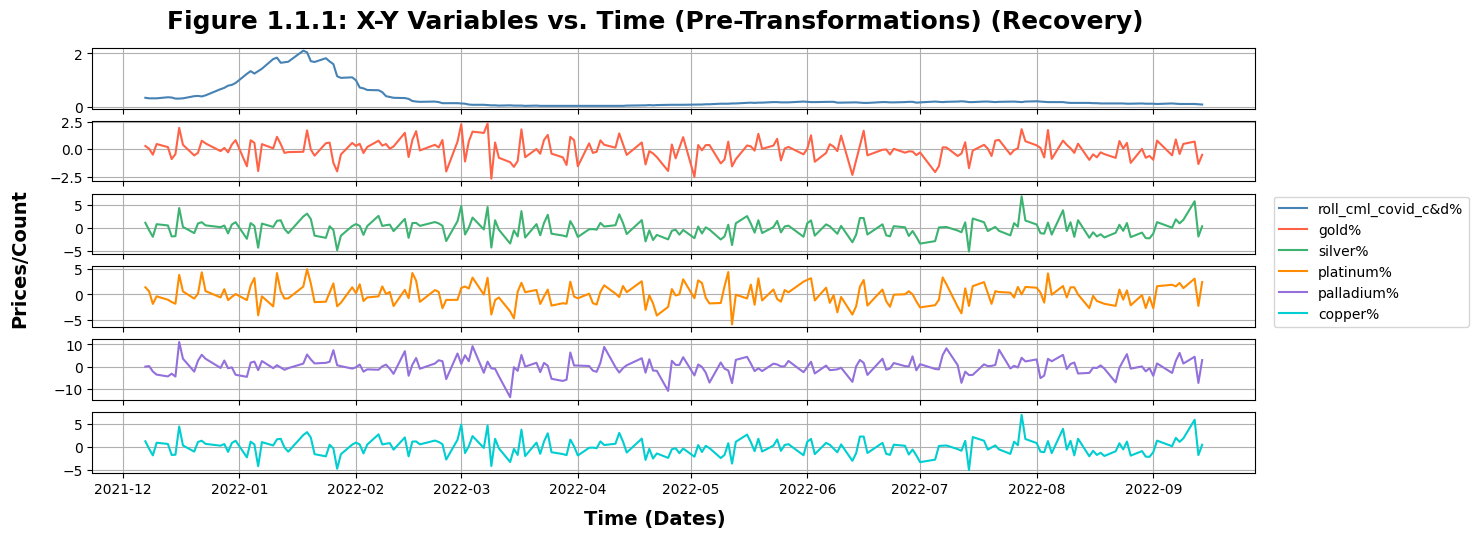

In [16]:
title = f'Figure 1.1.1: X-Y Variables vs. Time (Pre-Transformations) {PRD}'

econ_anlys_vrb.set_coords('1.1.1', PRD, XCAT, YCOL)


matplotlibx.setup_stacked_line_charts(len(ttl_dict))

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices/Count')

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.01)

matplotlibx.set_line_multichart_supylabel_xycoords(0.07, 0.5)


matplotlibx.line_multichart(test_df, title)

## **1.1.2: Transformation: X-Y Variables**

### **The Zivot-Andrews Test: X-Y Variables (Pre-Transformations)**

In [17]:
title = 'Table 1.1.2.1: The Zivot-Andrews Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.zivot_andrews_test_summ_df(ttl_dict, autolag = 'AIC')

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,za_stat,p_value,1%,5%,10%,n_obs,lags_used,break_sq_idx,break_index,break_pct,regr_mthd,autolag,rejects_5pct,stationary
series,,,,,,,,,,,,,,
roll_cml_covid_c&d%,-12.98,0.0000,-5.28,-4.81,-4.57,194,14,32,2022-01-24,16.5%,constant only,AIC,True,stationary with break
gold%,-15.63,0.0000,-5.28,-4.81,-4.57,194,0,62,2022-03-08,32.0%,constant only,AIC,True,stationary with break
silver%,-14.53,0.0010,-5.03,-4.41,-4.14,194,0,143,2022-07-05,73.7%,trend only,AIC,True,stationary with break
platinum%,-13.37,0.0011,-5.03,-4.41,-4.14,194,0,142,2022-07-01,73.2%,trend only,AIC,True,stationary with break
palladium%,-9.40,0.0000,-5.28,-4.81,-4.57,194,2,63,2022-03-09,32.5%,constant only,AIC,True,stationary with break
copper%,-14.53,0.0010,-5.03,-4.41,-4.14,194,0,143,2022-07-05,73.7%,trend only,AIC,True,stationary with break


### **The Bai-Perron Test: X-Y Variables (Pre-Transformations)**

In [18]:
title = 'Table 1.1.2.2: The Bai-Perron Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.bai_perron_test_summ_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,n_breaks,break_indices,break_pcts,n_obs,model,model_desc,algorithm
series,,,,,,,
roll_cml_covid_c&d%,1,[45],[23.2],194,l2,mean shift detection (changes in level),pelt
gold%,0,n/a,n/a,194,l2,mean shift detection (changes in level),pelt
silver%,1,[65],[33.5],194,l2,mean shift detection (changes in level),pelt
platinum%,0,n/a,n/a,194,l2,mean shift detection (changes in level),pelt
palladium%,2,"[65, 130]","[33.5, 67.0]",194,l2,mean shift detection (changes in level),pelt
copper%,1,[65],[33.5],194,l2,mean shift detection (changes in level),pelt


### **The Augmented Dickey-Fuller (ADF) Test: X-Y Variables (Pre-Transformations)**

In [19]:
title = 'Table 1.1.2.3: The Augmented Dickey-Fuller (ADF) Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.adf_test_summ_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,adf_stat,p_value,used_lag,n_obs,1%,5%,10%,margin,regr. mthd.,autolag,stationary
series,,,,,,,,,,,
roll_cml_covid_c&d%,-5.28,0.0003,7,186,-4.43,-3.86,-3.57,-1.41,"constant, and linear and quadratic trend",BIC,True
gold%,-15.08,0.0000,0,193,-2.58,-1.94,-1.62,-13.13,"no constant, no trend",BIC,True
silver%,-14.41,0.0000,0,193,-2.58,-1.94,-1.62,-12.47,"no constant, no trend",BIC,True
platinum%,-13.39,0.0000,0,193,-2.58,-1.94,-1.62,-11.45,"no constant, no trend",BIC,True
palladium%,-12.90,0.0000,0,193,-2.58,-1.94,-1.62,-10.96,"no constant, no trend",BIC,True
copper%,-14.41,0.0000,0,193,-2.58,-1.94,-1.62,-12.47,"no constant, no trend",BIC,True


### **The Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test: X-Y Variables (Pre-Transformations)** 

In [20]:
title = 'Table 1.1.2.4: The KPSS Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.kpss_test_summ_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,kpss_stat,p_value,n_lags,n_lags_used,1%,5%,10%,margin,regr. mthd.,stationary
series,,,,,,,,,,
roll_cml_covid_c&d%,0.13,0.0821,legacy,15,0.22,0.15,0.12,-0.02,constant and trend,True
gold%,0.28,0.1000,legacy,15,0.74,0.46,0.35,-0.18,constant only,True
silver%,0.15,0.1000,legacy,15,0.74,0.46,0.35,-0.31,constant only,True
platinum%,0.08,0.1000,None,5,0.74,0.46,0.35,-0.38,constant only,True
palladium%,0.09,0.1000,None,5,0.74,0.46,0.35,-0.38,constant only,True
copper%,0.15,0.1000,legacy,15,0.74,0.46,0.35,-0.31,constant only,True


### **Cross-Validation for Stationarity - X-Y Variables (Pre-Transformations)** 

In [21]:
title = 'Table 1.1.2.5: The Cross-Validation for Stationarity ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.crss_valid_for_stnry_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,adf_stationary,kpss_stationary,result,conclusion,recommendation
series,,,,,
roll_cml_covid_c&d%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
gold%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
silver%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
platinum%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
palladium%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
copper%,True,True,stationary,Both tests agree the series is stationary.,No action needed.


### **Transformations for Stationarity - X-Y Variables**

In [22]:
trns_df = mathx.crct_stnry_df(ttl_dict)

STATIONARY TIME SERIES DETECTED: roll_cml_covid_c&d%.


STATIONARY TIME SERIES DETECTED: gold%.


STATIONARY TIME SERIES DETECTED: silver%.


STATIONARY TIME SERIES DETECTED: platinum%.


STATIONARY TIME SERIES DETECTED: palladium%.


STATIONARY TIME SERIES DETECTED: copper%.




### **Cross-Validation for Stationarity - X-Y Variables (Post-Transformations)** 

In [23]:
title = 'Table 1.1.2.6: Corrections for Stationarity ' \
            + f'- {XTTL} vs. {YSBJ} (Post-Transformations) {PRD}'

test_df = mathx.crss_valid_for_stnry_df(trns_df.to_dict(orient = 'series'))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,adf_stationary,kpss_stationary,result,conclusion,recommendation
series,,,,,
roll_cml_covid_c&d%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
gold%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
silver%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
platinum%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
palladium%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
copper%,True,True,stationary,Both tests agree the series is stationary.,No action needed.


### **The Zivot-Andrews Test: X-Y Variables (Post-Transformations)**

In [24]:
title = 'Table 1.1.2.7: The Zivot-Andrews Test ' \
            + f'- {XTTL} vs. {YSBJ} (Post-Transformations) {PRD}'

test_df = mathx.zivot_andrews_test_summ_df(trns_df.to_dict(orient = 'series'))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,za_stat,p_value,1%,5%,10%,n_obs,lags_used,break_sq_idx,break_index,break_pct,regr_mthd,autolag,rejects_5pct,stationary
series,,,,,,,,,,,,,,
roll_cml_covid_c&d%,-8.14,0.0009,-5.58,-5.07,-4.83,194,7,32,2022-01-24,16.5%,constant and trend,BIC,True,stationary with break
gold%,-15.63,0.0000,-5.28,-4.81,-4.57,194,0,62,2022-03-08,32.0%,constant only,BIC,True,stationary with break
silver%,-14.53,0.0010,-5.03,-4.41,-4.14,194,0,143,2022-07-05,73.7%,trend only,BIC,True,stationary with break
platinum%,-13.37,0.0011,-5.03,-4.41,-4.14,194,0,142,2022-07-01,73.2%,trend only,BIC,True,stationary with break
palladium%,-12.93,0.0012,-5.03,-4.41,-4.14,194,0,105,2022-05-09,54.1%,trend only,BIC,True,stationary with break
copper%,-14.53,0.0010,-5.03,-4.41,-4.14,194,0,143,2022-07-05,73.7%,trend only,BIC,True,stationary with break


### **The Bai-Perron Test: X-Y Variables (Post-Transformations)**

In [25]:
title = 'Table 1.1.2.8: The Bai-Perron Test ' \
            + f'- {XTTL} vs. {YSBJ} (Post-Transformations) {PRD}'

test_df = mathx.bai_perron_test_summ_df(trns_df.to_dict(orient = 'series'))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,n_breaks,break_indices,break_pcts,n_obs,model,model_desc,algorithm
series,,,,,,,
roll_cml_covid_c&d%,1,[45],[23.2],194,l2,mean shift detection (changes in level),pelt
gold%,0,n/a,n/a,194,l2,mean shift detection (changes in level),pelt
silver%,1,[65],[33.5],194,l2,mean shift detection (changes in level),pelt
platinum%,0,n/a,n/a,194,l2,mean shift detection (changes in level),pelt
palladium%,2,"[65, 130]","[33.5, 67.0]",194,l2,mean shift detection (changes in level),pelt
copper%,1,[65],[33.5],194,l2,mean shift detection (changes in level),pelt


### **Display X-Y Variables (Post-Transformations)**

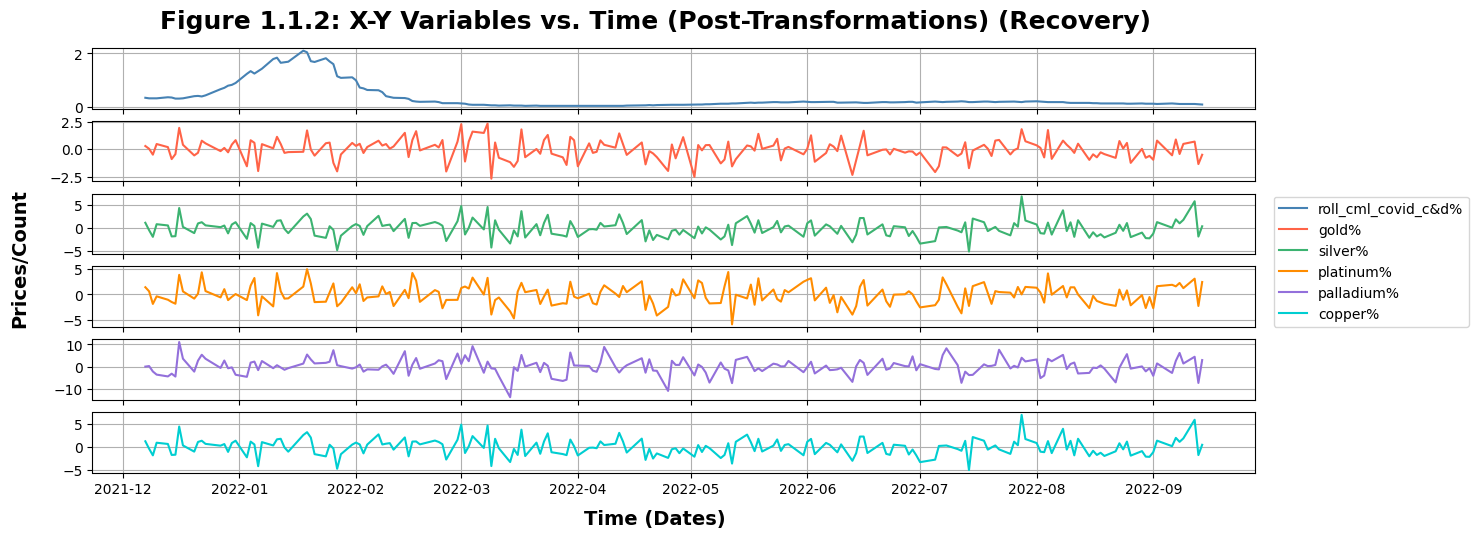

In [26]:
title = f'Figure 1.1.2: X-Y Variables vs. Time (Post-Transformations) {PRD}'

econ_anlys_vrb.set_coords('1.1.2', PRD, XCAT, YCOL)
        

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices/Count')

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.01)

matplotlibx.set_line_multichart_supylabel_xycoords(0.07, 0.5)


matplotlibx.line_multichart(trns_df, title)

### **Assign Data to Series - X-Y Variables (Post-Transformations)**

In [27]:
if YPCT:

    x_series  = trns_df[XCAT]

    y1_series = trns_df[YCAT[Y.Y1.value] + '%']

    y2_series = trns_df[YCAT[Y.Y2.value] + '%']

    y3_series = trns_df[YCAT[Y.Y3.value] + '%']

    y4_series = trns_df[YCAT[Y.Y4.value] + '%']

    y5_series = trns_df[YCAT[Y.Y5.value] + '%']

else:

    x_series  = trns_df[XCAT]

    y1_series = trns_df[YCAT[Y.Y1.value]]

    y2_series = trns_df[YCAT[Y.Y2.value]]

    y3_series = trns_df[YCAT[Y.Y3.value]]

    y4_series = trns_df[YCAT[Y.Y4.value]]

    y5_series = trns_df[YCAT[Y.Y5.value]]

## **1.1.3: X vs. Y1**

### **Create DataFrame X vs. Y1**

In [28]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y1.value]: y1_series})

logx.log_write_obj(comp_df)

In [29]:
title = f'Table 1.1.3.1: {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y1.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_c&d%,gold
series,,
2021-12-07,0,0
2021-12-08,0,0
2021-12-09,0,-0
2021-12-10,0,0
2021-12-13,0,0
2021-12-14,0,-1
2021-12-15,0,-0
2021-12-16,0,2
2021-12-17,0,0


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y1**

In [30]:
title = 'Table 1.1.3.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y1_series, x_series)

corr_method = mathx.find_opt_corr_method(y1_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.00,-50.99,57.69,1.00,-301.38,1.00,True,1.00
2,0.00,-54.18,61.96,0.96,-299.72,0.87,True,0.91
3,0.01,-54.36,60.92,0.96,-298.63,0.78,True,0.87
4,0.01,-53.96,59.75,0.96,-296.82,0.63,True,0.80
5,0.01,-55.27,60.58,0.95,-295.95,0.56,True,0.75
6,0.02,-71.59,94.37,0.74,-295.86,0.55,True,0.65
7,0.03,-70.66,92.40,0.75,-294.06,0.41,True,0.58
8,0.03,-72.79,95.41,0.73,-292.20,0.26,True,0.49
9,0.03,-95.47,86.56,0.44,-290.90,0.15,True,0.30
10,0.03,-130.78,118.63,0.00,-289.01,0.00,True,0.00


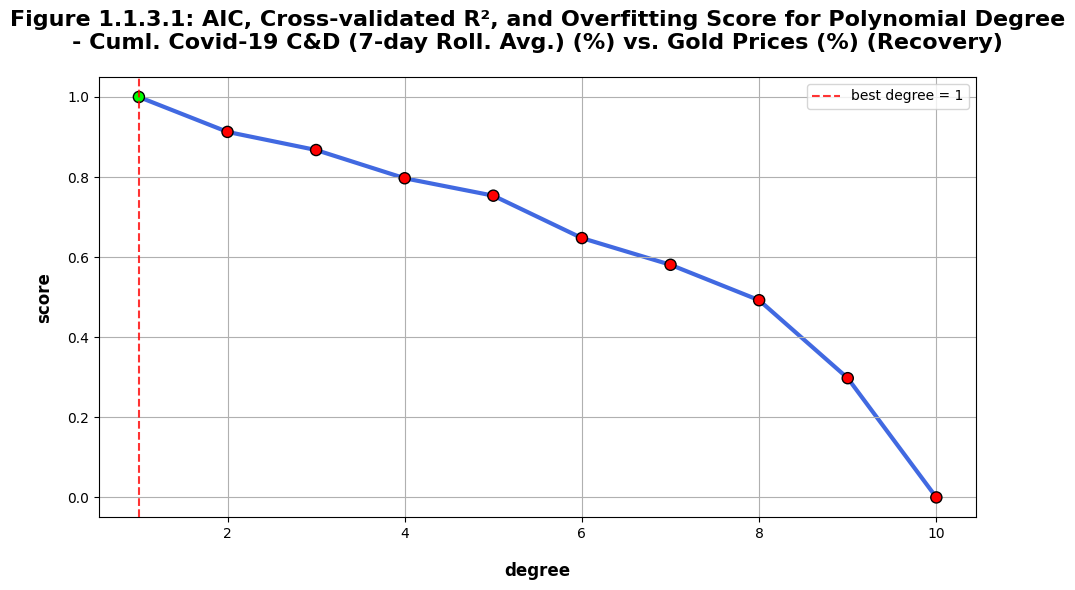

In [31]:
title = 'Figure 1.1.3.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y1**

In [32]:
title = f'Table 1.1.3.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_c&d%,gold
roll_cml_covid_c&d%,1.00,0.08
gold,0.08,1.00


### **Scatter Plot: X vs. Y1**

r-value (pearson):	0.043
r-value (spearman):	0.081
tau (kendall):		0.062

p-value (pearson):	0.551
p-value (spearman):	0.263
p-value (kendall):	0.205




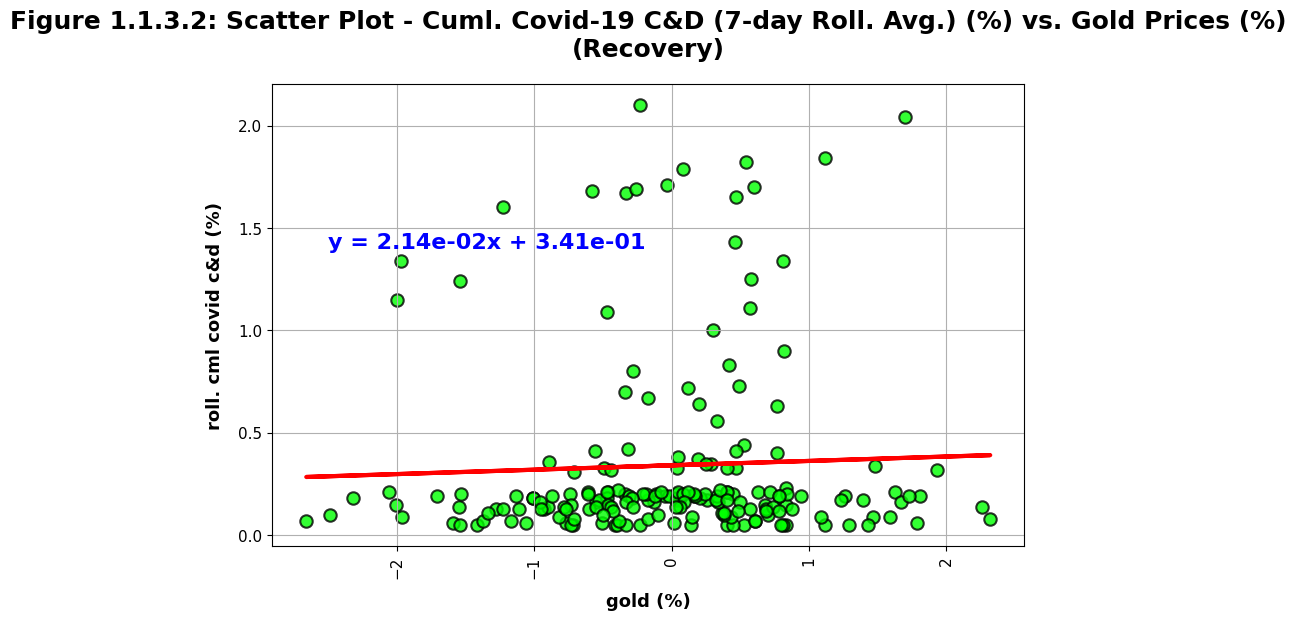

In [33]:
title = 'Figure 1.1.3.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.3.2', PRD, XCAT, YCOL)


matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y1.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y1_series, x_series], title)

### **The Granger Causality Test: X -> Y1**

In [34]:
title = 'Table 1.1.3.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y1.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y1_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y1_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y1_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list = [best_dict]

grngr_nm_list  = [f'{XCAT} -> {YCAT[Y.Y1.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.488296,0.485543,False,False,False,False,high confidence
2,2.247795,0.108479,False,False,False,False,high confidence
3,1.660843,0.177028,False,False,False,False,high confidence
4,1.821101,0.126634,False,False,False,False,high confidence
5,1.302988,0.264675,False,False,False,False,high confidence
6,1.220031,0.298118,False,False,False,False,high confidence
7,1.317663,0.244554,False,False,False,False,high confidence
8,1.586871,0.132001,False,False,False,False,high confidence


### **The Granger Causality Test: Y1 -> X**

In [35]:
title = 'Table 1.1.3.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y1.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y1_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y1.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.101146,0.750807,False,False,False,False,high confidence
2,0.130575,0.877670,False,False,False,False,high confidence
3,0.094916,0.962769,False,False,False,False,high confidence
4,0.814140,0.517635,False,False,False,False,high confidence
5,1.102468,0.360784,False,False,False,False,high confidence
6,0.403267,0.876179,False,False,False,False,high confidence
7,0.476601,0.850643,False,False,False,False,high confidence
8,0.395833,0.921689,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y1**

In [36]:
results_dict = mathx.fit_var_or_vecm(x_series, y1_series)

x_y1_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y1.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_C&D% VS. GOLD% ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.102070, p = 0.243683).

Series 'y' is stationary (ADF = -15.045446, p = 0.000000).

Trace rank = 2, max-eigenvalue rank=0 — using trace result. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 8.
AIC = 8, BIC = 8, HQIC = 8, FPE = 8.

VECM(lag = 7, rank = 1) fitted. Adjustment speeds — x: -0.000358, y: 0.127317. Error correction half-life: inf periods. x - (8.962329) * y = 0  (long-run equilibrium). Mean reversion: CONFIRMED.

IRF (VECM, 30 periods):
A one-SD shock to x produces a positive net response in y.
Peak x→y effect at lag 1 (magnitude: 3.268658).
Cumulative x→y response: 6.571837.

FEVD (VECM, horizon = 31):
x shocks explain 6.944308% of y's forecast variance (moderate influence).
y's own shocks explain 93.055692% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y1**

In [37]:
title = 'Table 1.1.3.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    irf_bool = True

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y1.value]} {PRD}\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y1.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,1.028018,3.268658,0.000974,-0.092843
2,1.166667,1.272106,0.004665,-0.050169
3,1.349955,-0.763419,0.003862,0.129608
4,1.645071,1.149288,0.003930,0.014649
5,2.224701,0.336656,0.001080,0.049604
6,2.464309,0.488945,0.006769,-0.100590
7,2.239126,-0.454621,0.008106,-0.024988
8,2.542527,-1.496562,0.006822,-0.011637


### **Forecast Error Variance Decomposition (FEVD): X vs. Y1**

In [38]:
if irf_bool:
    
    title = 'Table 1.1.3.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

else:

    title = 'Table 1.1.3.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'    

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.002725,0.997275,1.000000,0.000000
1,0.041118,0.958882,0.999672,0.000328
2,0.046304,0.953696,0.996687,0.003313
3,0.048175,0.951825,0.996215,0.003785
4,0.051458,0.948542,0.996329,0.003671
5,0.051513,0.948487,0.997631,0.002369
6,0.051754,0.948246,0.997133,0.002867
7,0.052521,0.947479,0.996262,0.003738
8,0.057233,0.942767,0.996253,0.003747


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y1**

In [39]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y1_series, method = corr_method)

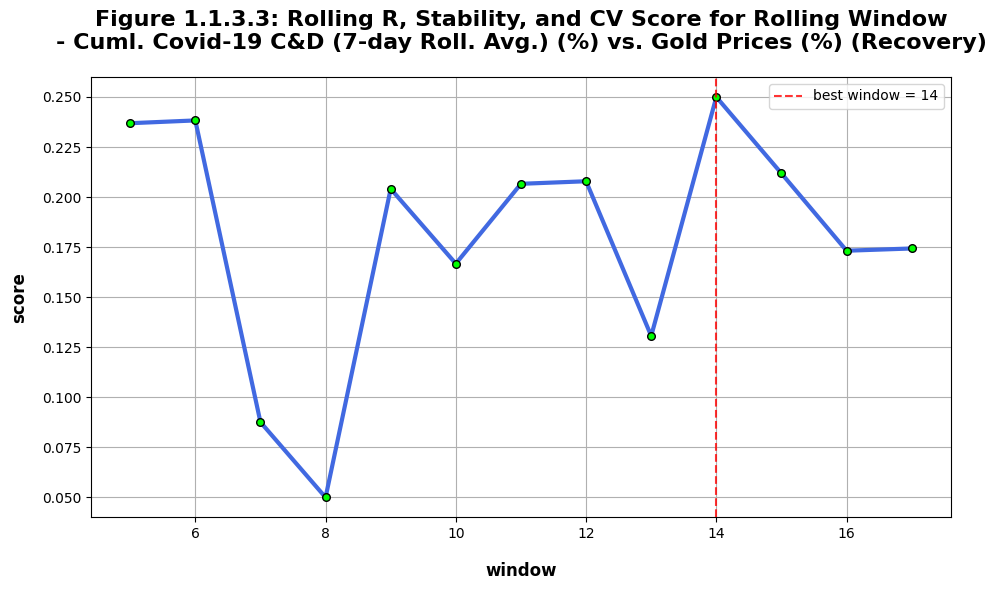

In [40]:
title = 'Figure 1.1.3.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y1**

In [41]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y1_series, best_w, method = corr_method)

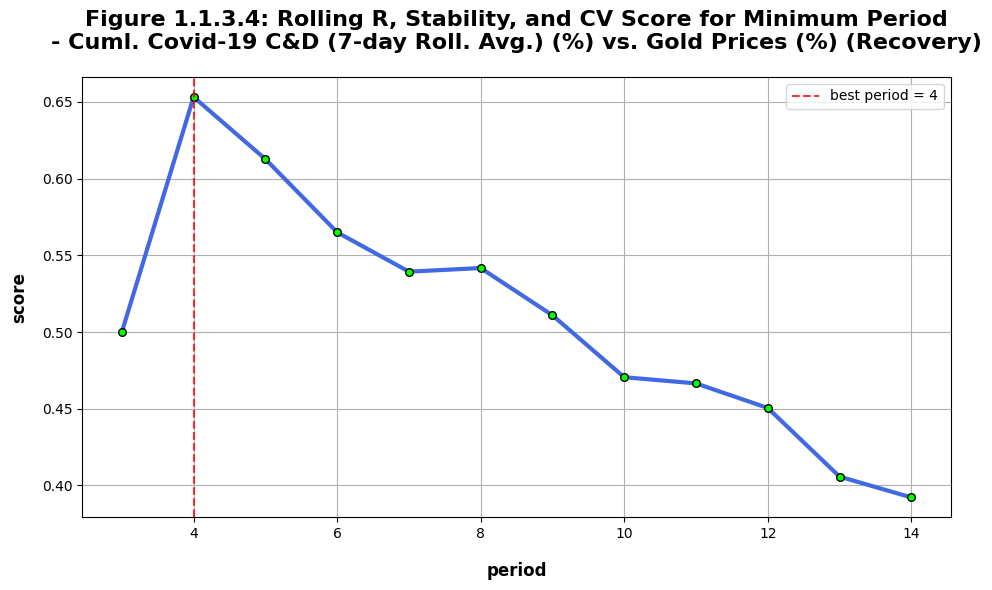

In [42]:
title = 'Figure 1.1.3.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y1**

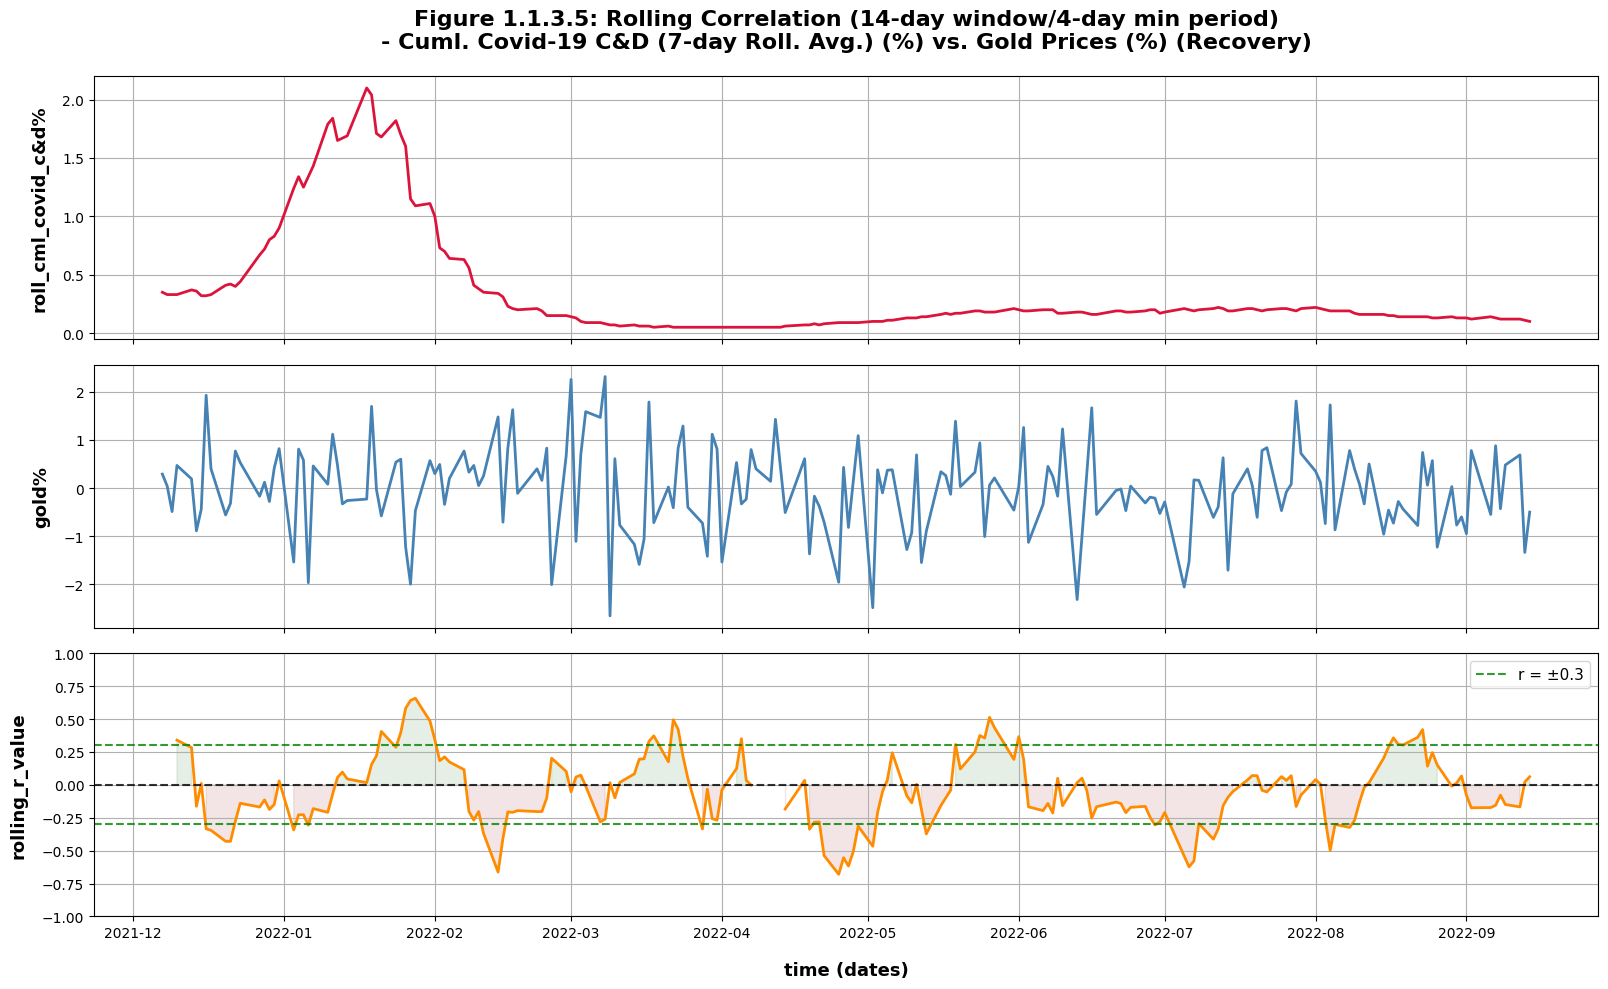

In [43]:
title \
    = f'Figure 1.1.3.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_roll_corr_xylabels('time (dates)', [])

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)


matplotlibx.plot_rolling_corr_lines(x_series, y1_series, title)

### **Lag Correlation: X vs. Y1**

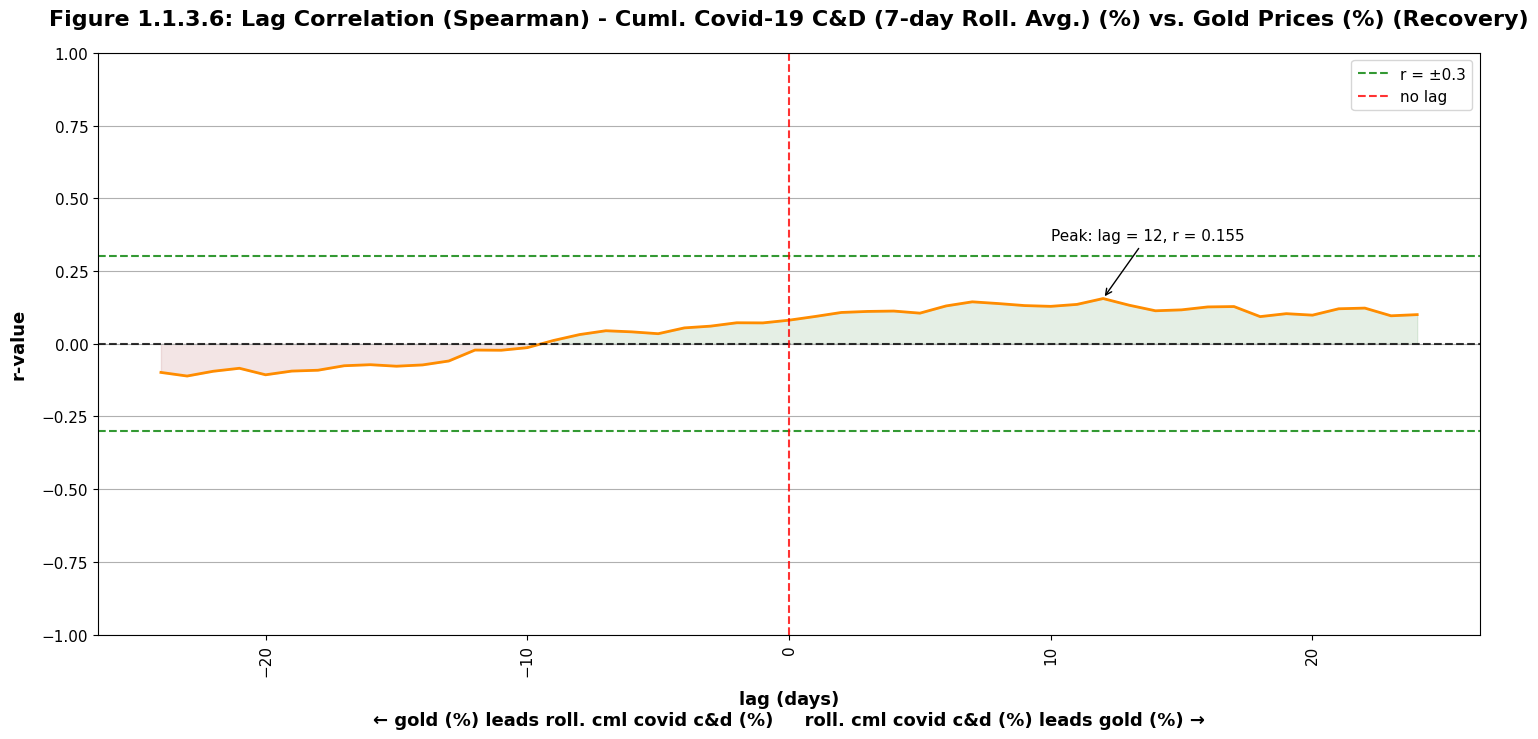

In [44]:
title = f'Figure 1.1.3.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.3.6', PRD, XCAT, YCOL)


v_lag       = int(x_y1_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y1_series, v_lag, g_lag)

max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y1.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y1_series, title, max_lag = max_lag)

## **1.1.4: X vs. Y2**

### **Create DataFrame X vs. Y2**

In [45]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y2.value]: y2_series})

logx.log_write_obj(comp_df)

In [46]:
title = f'Table 1.1.4.1: {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y2.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_c&d%,silver
series,,
2021-12-07,0,1
2021-12-08,0,-0
2021-12-09,0,-2
2021-12-10,0,1
2021-12-13,0,1
2021-12-14,0,-2
2021-12-15,0,-2
2021-12-16,0,4
2021-12-17,0,0


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y2**

In [47]:
title = 'Table 1.1.4.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y2_series, x_series)

corr_method = mathx.find_opt_corr_method(y2_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.00,-51.24,57.15,1.00,-301.56,0.96,True,0.98
2,0.00,-52.92,58.10,1.00,-299.57,0.71,True,0.86
3,0.02,-64.84,78.72,1.00,-301.88,1.00,True,1.00
4,0.03,-97.23,109.46,1.00,-300.18,0.79,True,0.89
5,0.03,-182.30,222.31,1.00,-298.56,0.59,True,0.79
6,0.03,-513.61,792.19,1.00,-296.83,0.38,True,0.69
7,0.03,"-2,217.11","4,150.73",0.99,-295.40,0.20,True,0.59
8,0.04,"-4,094.09","7,970.44",0.98,-295.56,0.22,True,0.60
9,0.04,"-209,556.46","418,839.85",0.00,-293.79,0.00,True,0.00
10,0.06,"-7,059.60","14,003.41",0.97,-294.82,0.13,True,0.55


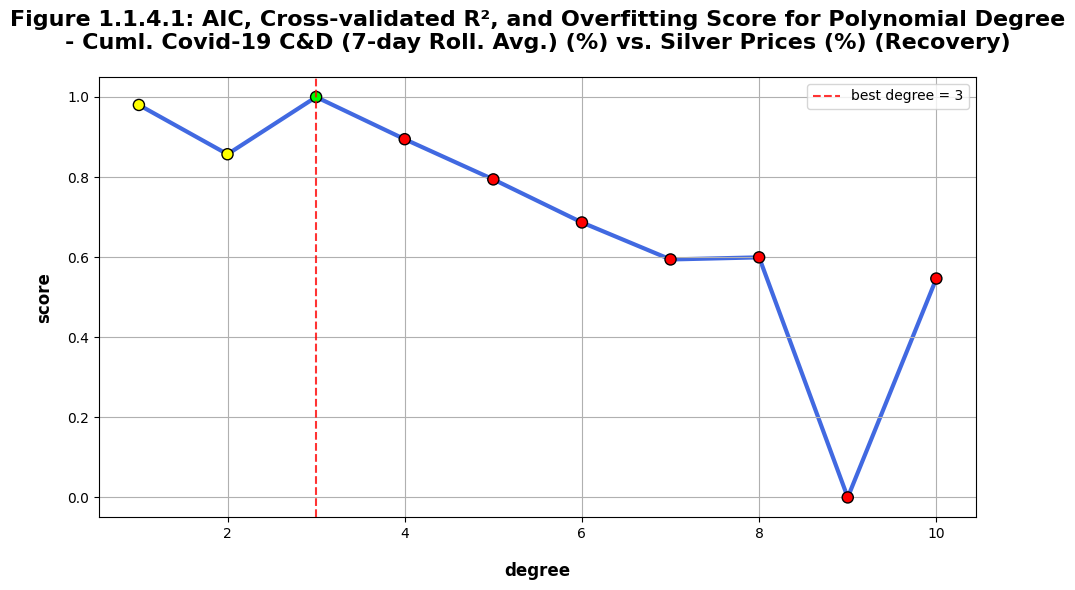

In [48]:
title = 'Figure 1.1.4.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y2**

In [49]:
title = f'Table 1.1.4.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_c&d%,silver
roll_cml_covid_c&d%,1.00,0.11
silver,0.11,1.00


### **Scatter Plot: X vs. Y2**

r-value (pearson):	0.053
r-value (spearman):	0.111
tau (kendall):		0.076

p-value (pearson):	0.466
p-value (spearman):	0.122
p-value (kendall):	0.121




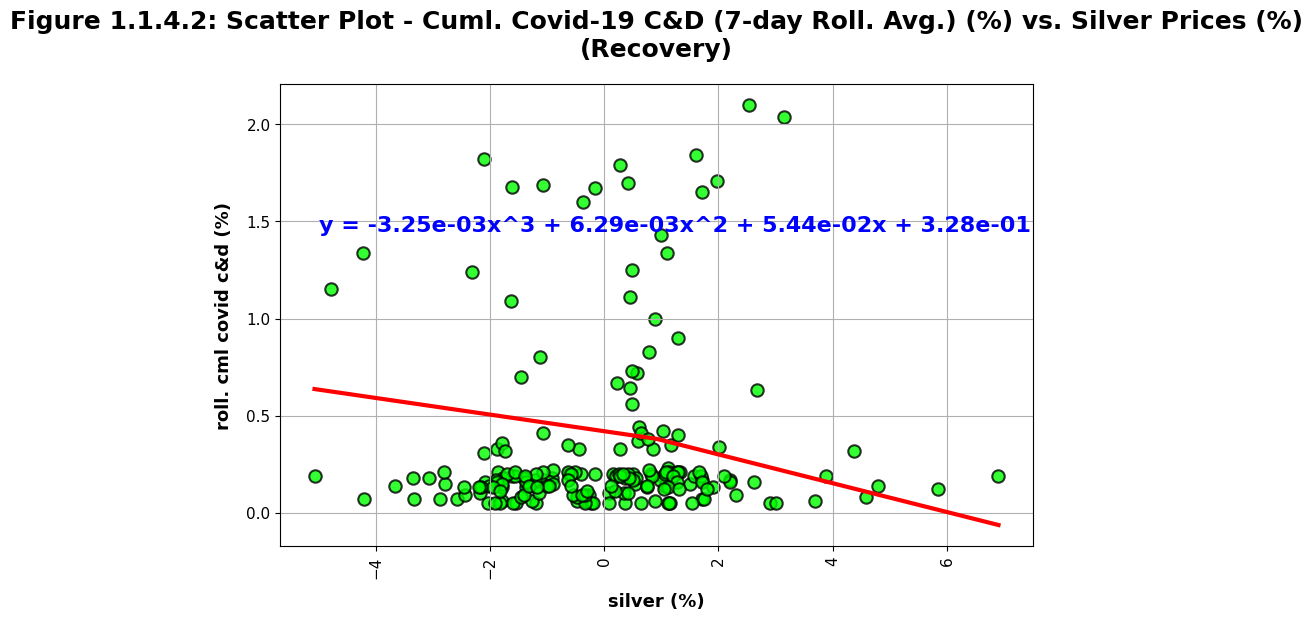

In [50]:
title = 'Figure 1.1.4.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.4.2', PRD, XCAT, YCOL)


matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y2.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y2_series, x_series], title)

### **The Granger Causality Test: X -> Y2**

In [51]:
title = 'Table 1.1.4.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y2.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y2_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y2_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y2_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y2.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.507201,0.477227,False,False,False,False,high confidence
2,2.986080,0.052898,False,True,True,False,non-normal residuals or insufficient sample size
3,2.257761,0.083210,False,False,False,False,high confidence
4,3.365650,0.011003,True,True,True,True,high confidence


### **The Granger Causality Test: Y2 -> X**

In [52]:
title = 'Table 1.1.4.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y2.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y2_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y2.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.706113,0.401793,False,False,False,False,high confidence
2,0.495913,0.609813,False,False,False,False,high confidence
3,0.664503,0.574868,False,False,False,False,high confidence
4,1.434763,0.224272,False,False,False,False,high confidence
5,1.135650,0.343222,False,False,False,False,high confidence
6,0.783520,0.583907,False,False,False,False,high confidence
7,0.923012,0.490061,False,False,False,False,high confidence
8,1.166748,0.322043,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y2**

In [53]:
results_dict = mathx.fit_var_or_vecm(x_series, y2_series)

x_y2_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y2.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_C&D% VS. SILVER% ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.102070, p = 0.243683).

Series 'y' is stationary (ADF = -14.388596, p = 0.000000).

Trace rank = 2, max-eigenvalue rank=0 — using trace result. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 8.
AIC = 12, BIC = 8, HQIC = 8, FPE = 12.

VECM(lag = 7, rank = 1) fitted. Adjustment speeds — x: 0.000257, y: 0.052435. Error correction half-life: inf periods. x - (18.100914) * y = 0  (long-run equilibrium). Mean reversion: NOT CONFIRMED — check alpha signs.

IRF (VECM, 30 periods):
A one-SD shock to x produces a positive net response in y.
Peak x→y effect at lag 2 (magnitude: 5.024129).
Cumulative x→y response: 5.402338.

FEVD (VECM, horizon = 31):
x shocks explain 7.091675% of y's forecast variance (moderate influence).
y's own shocks explain 92.908325% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y2**

In [54]:
title = 'Table 1.1.4.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y2.value]} {PRD}\n')

except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y2.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,1.033951,4.114145,0.000742,-0.035422
2,1.172093,5.024129,0.002739,0.114040
3,1.346741,-3.160029,0.001628,0.086506
4,1.654108,1.163526,0.000067,-0.037905
5,2.237358,1.831768,-0.002315,0.006992
6,2.473575,1.323966,0.001126,-0.059194
7,2.241482,-0.139382,-0.000652,0.056356
8,2.548047,-2.471550,-0.004408,-0.068226


### **Forecast Error Variance Decomposition (FEVD): X vs. Y2**

In [55]:
if irf_bool:
    
    title = 'Table 1.1.4.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

else:

    title = 'Table 1.1.4.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}') 

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.000204,0.999796,1.000000,0.000000
1,0.018051,0.981949,0.999183,0.000817
2,0.037453,0.962547,0.994348,0.005652
3,0.043298,0.956702,0.994113,0.005887
4,0.044621,0.955379,0.995667,0.004333
5,0.047028,0.952972,0.997166,0.002834
6,0.047977,0.952023,0.997106,0.002894
7,0.047970,0.952030,0.997355,0.002645
8,0.050521,0.949479,0.997731,0.002269


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y2**

In [56]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y2_series, method = corr_method)

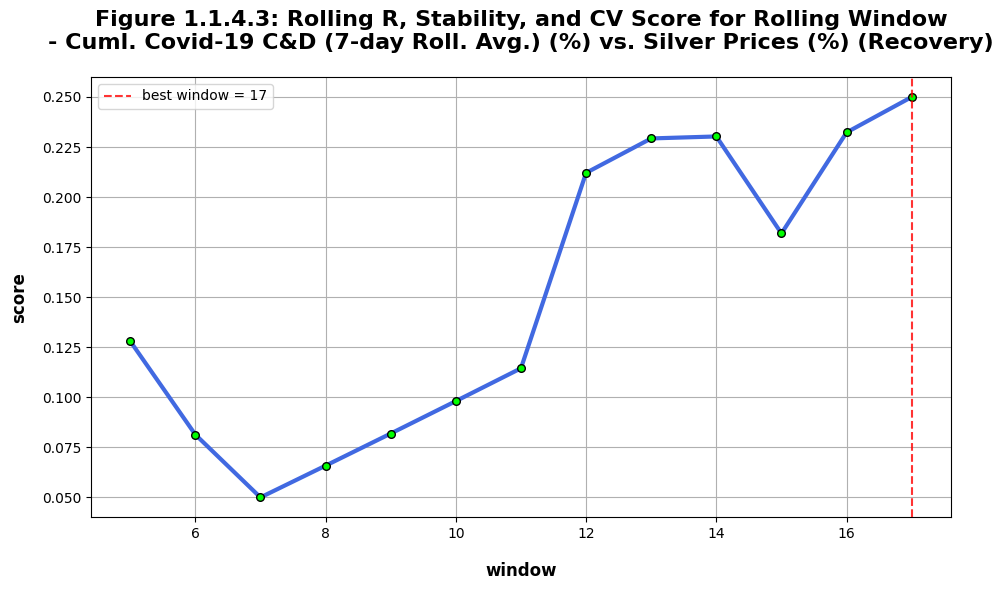

In [57]:
title = 'Figure 1.1.4.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y2**

In [58]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y2_series, best_w, method = corr_method)

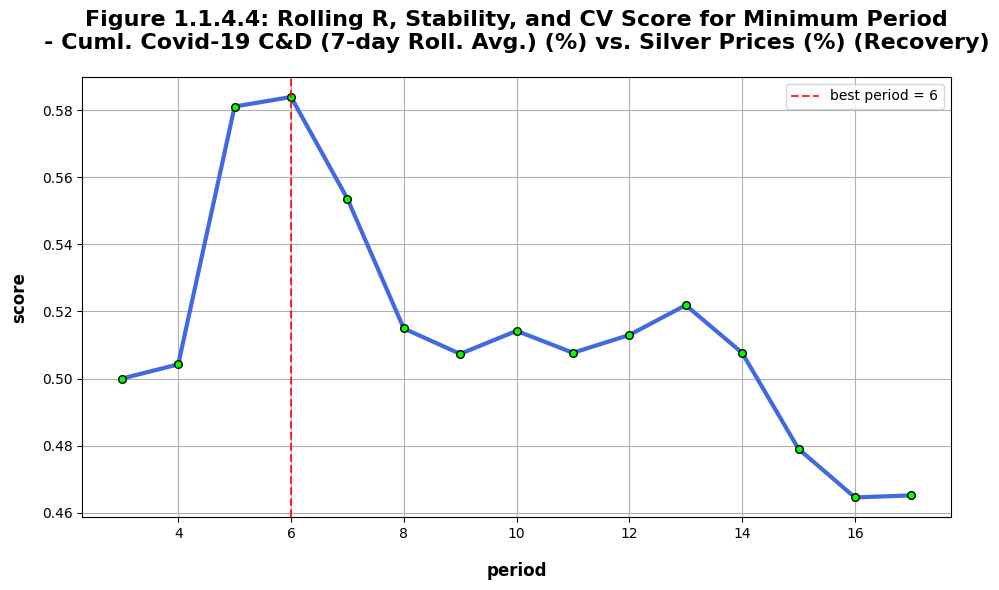

In [59]:
title = 'Figure 1.1.4.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y2**

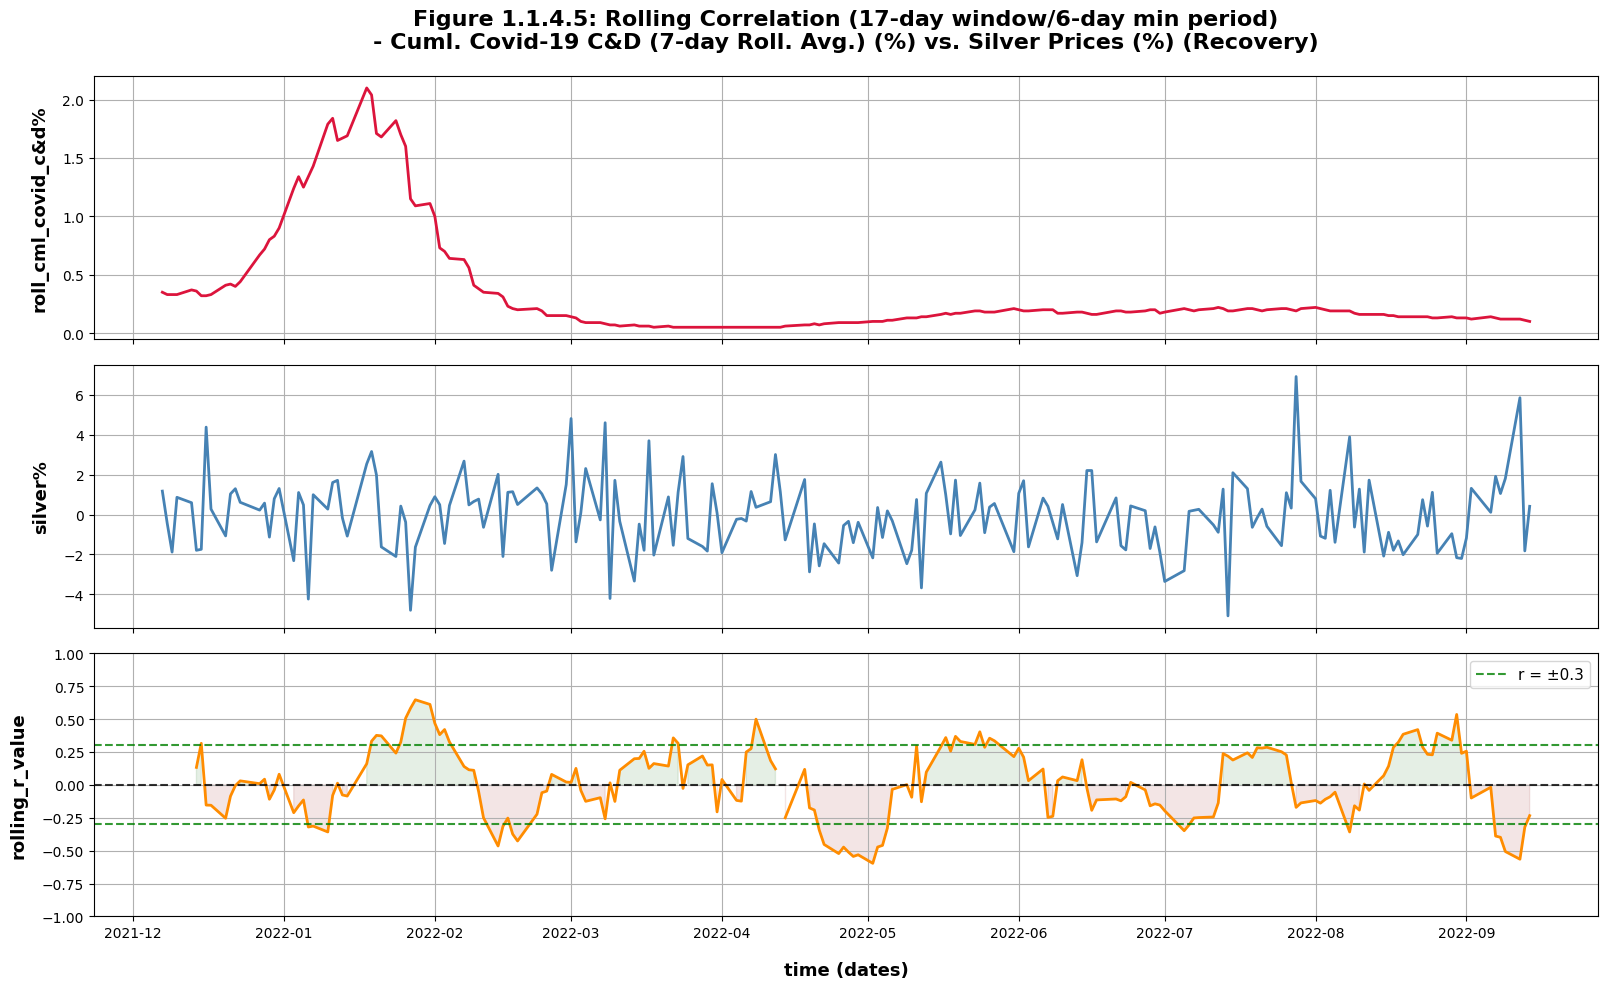

In [60]:
title \
    = f'Figure 1.1.4.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y2_series, title)

### **Lag Correlation: X vs. Y2**

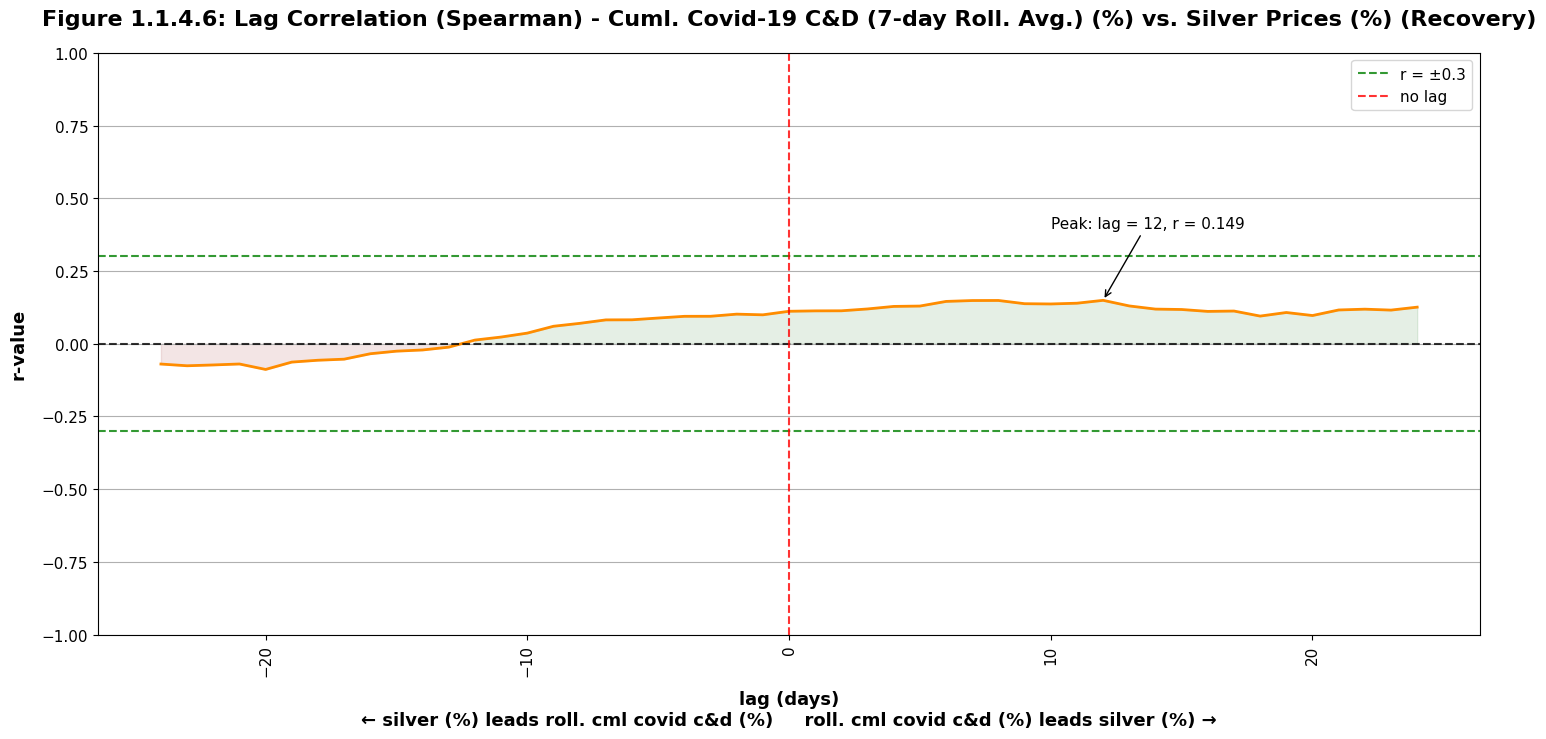

In [61]:
title = f'Figure 1.1.4.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.4.6', PRD, XCAT, YCOL)


v_lag       = int(x_y2_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y2_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y2.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y2_series, title, max_lag = max_lag)

## **1.1.5: X vs. Y3**

### **Create DataFrame X vs. Y3**

In [62]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y3.value]: y3_series})

logx.log_write_obj(comp_df)

In [63]:
title = f'Table 1.1.5.1: {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y3.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_c&d%,platinum
series,,
2021-12-07,0,1
2021-12-08,0,1
2021-12-09,0,-2
2021-12-10,0,-0
2021-12-13,0,-1
2021-12-14,0,-1
2021-12-15,0,-2
2021-12-16,0,4
2021-12-17,0,1


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y3**

In [64]:
title = 'Table 1.1.5.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y3_series, x_series)

corr_method = mathx.find_opt_corr_method(y3_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.01,-52.55,58.84,1.00,-302.61,0.30,True,0.65
2,0.01,-53.19,59.87,1.00,-301.26,0.00,True,0.50
3,0.03,-53.72,59.75,1.00,-303.03,0.39,True,0.69
4,0.05,-49.05,48.36,1.00,-305.00,0.82,True,0.91
5,0.06,-45.17,45.99,1.00,-305.44,0.92,True,0.96
6,0.07,-66.59,63.23,1.00,-304.85,0.79,True,0.89
7,0.08,-126.42,171.56,0.99,-305.81,1.00,True,0.99
8,0.08,"-1,121.29","2,154.59",0.85,-303.82,0.56,True,0.71
9,0.09,-900.94,"1,711.73",0.88,-302.97,0.38,True,0.63
10,0.09,"-7,069.74","14,042.96",0.00,-302.15,0.20,True,0.10


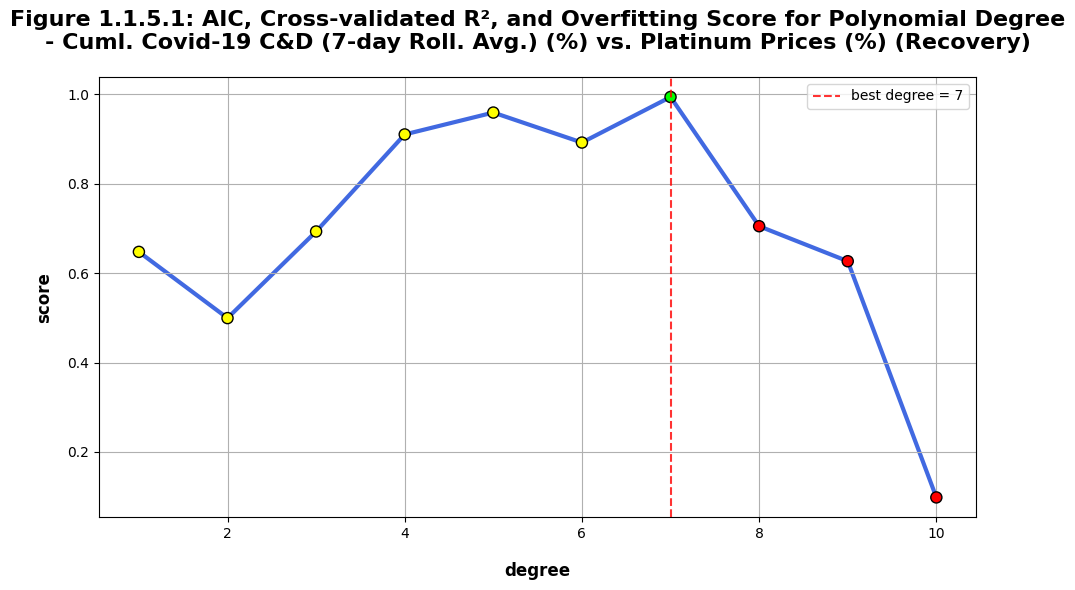

In [65]:
title = 'Figure 1.1.5.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y3**

In [66]:
title = f'Table 1.1.5.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_c&d%,platinum
roll_cml_covid_c&d%,1.00,0.09
platinum,0.09,1.00


### **Scatter Plot: X vs. Y3**

r-value (pearson):	0.090
r-value (spearman):	0.085
tau (kendall):		0.059

p-value (pearson):	0.211
p-value (spearman):	0.238
p-value (kendall):	0.234




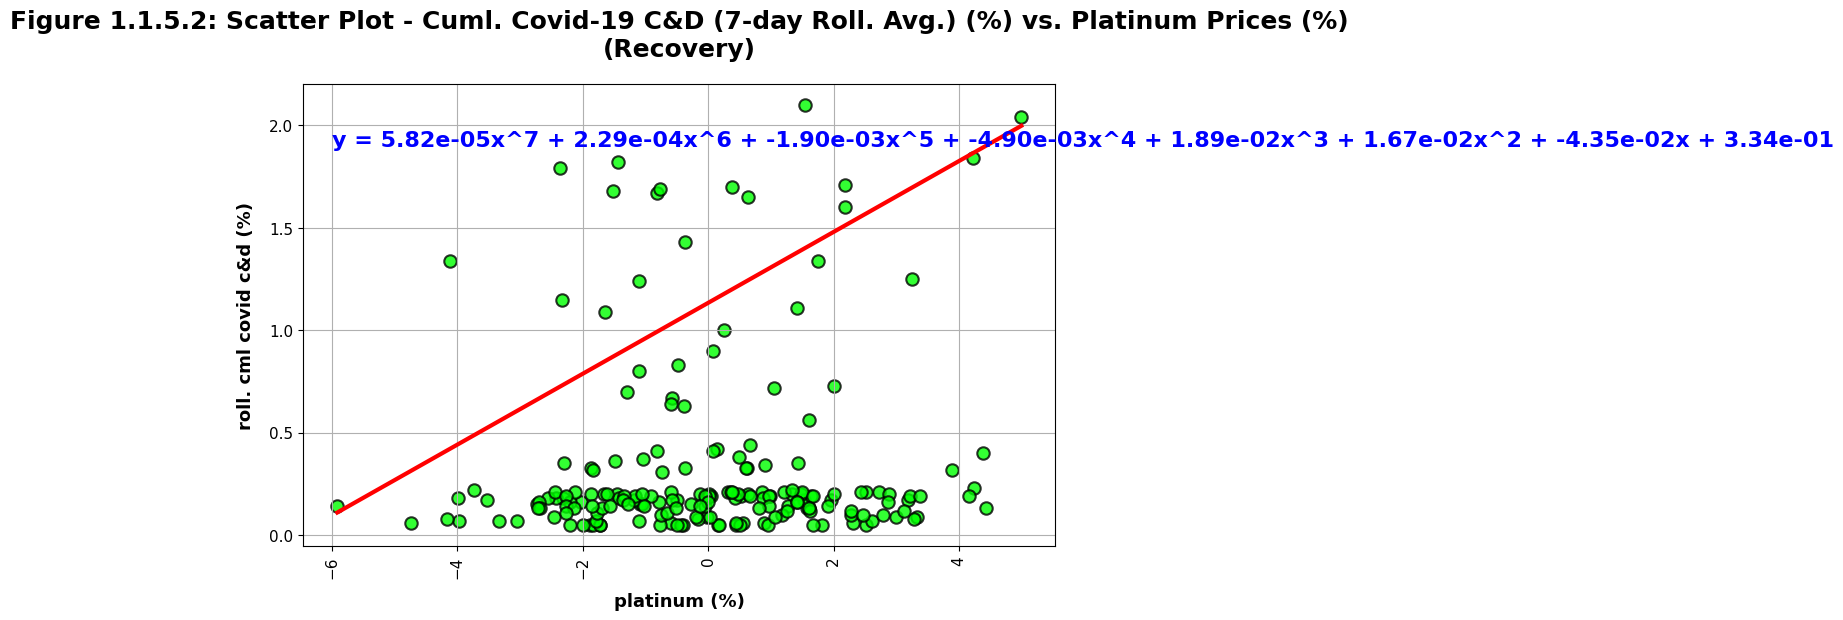

In [67]:
title = 'Figure 1.1.5.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.5.2', PRD, XCAT, YCOL)


matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y3.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y3_series, x_series], title)

### **The Granger Causality Test: X -> Y3**

In [68]:
title = 'Table 1.1.5.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y3.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y3_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y3_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y3_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y3.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,1.980421,0.160980,False,False,False,False,high confidence
2,4.497167,0.012371,True,True,True,True,high confidence


### **The Granger Causality Test: Y3 -> X**

In [69]:
title = 'Table 1.1.5.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y3.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y3_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y3.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,5.065084,0.025559,True,True,True,True,high confidence


### **VAR/VECM Analysis: X vs. Y3**

In [70]:
results_dict = mathx.fit_var_or_vecm(x_series, y3_series)

x_y3_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y3.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_C&D% VS. PLATINUM% ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.102070, p = 0.243683).

Series 'y' is stationary (ADF = -13.352636, p = 0.000000).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 8.
AIC = 8, BIC = 8, HQIC = 8, FPE = 8.

VECM(lag = 7, rank = 1) fitted. Adjustment speeds — x: 0.000879, y: 0.224091. Error correction half-life: inf periods. x - (5.652898) * y = 0  (long-run equilibrium). Mean reversion: NOT CONFIRMED — check alpha signs.

IRF (VECM, 30 periods):
A one-SD shock to x produces a positive net response in y.
Peak x→y effect at lag 1 (magnitude: 5.317753).
Cumulative x→y response: 20.064496.

FEVD (VECM, horizon = 31):
x shocks explain 7.890451% of y's forecast variance (moderate influence).
y's own shocks explain 92.109549% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y3**

In [71]:
title = 'Table 1.1.5.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y3.value]} {PRD}\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y3.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,1.033940,5.317753,-0.000382,0.019047
2,1.160629,1.487311,-0.000586,0.059550
3,1.343289,-0.768059,-0.001869,-0.085819
4,1.634231,-2.954439,-0.000243,0.025520
5,2.219725,0.187511,-0.003332,-0.166507
6,2.454292,2.586256,-0.002244,-0.037282
7,2.220884,2.102251,-0.004967,-0.081115
8,2.502386,-3.050222,-0.006480,-0.026607


### **Forecast Error Variance Decomposition (FEVD): X vs. Y3**

In [72]:
if irf_bool:
    
    title = 'Table 1.1.5.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

else:

    title = 'Table 1.1.5.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.002160,0.997840,1.000000,0.000000
1,0.025835,0.974165,1.000000,0.000000
2,0.028073,0.971927,0.999984,0.000016
3,0.027910,0.972090,0.999817,0.000183
4,0.032301,0.967699,0.999418,0.000582
5,0.031769,0.968231,0.999358,0.000642
6,0.035907,0.964093,0.999527,0.000473
7,0.037719,0.962281,0.999432,0.000568
8,0.042385,0.957615,0.999171,0.000829


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y3**

In [73]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y3_series, method = corr_method)

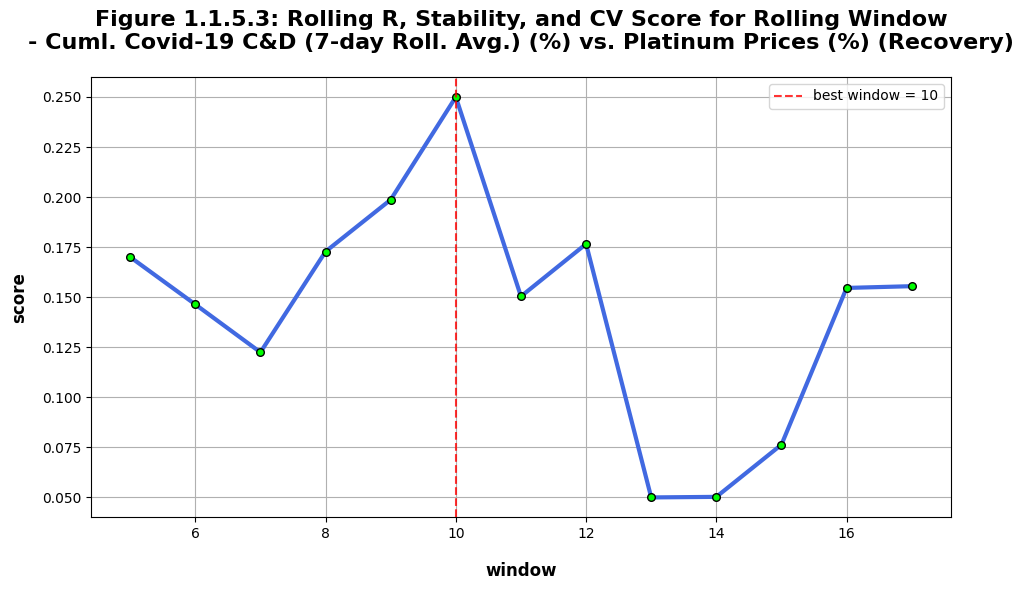

In [74]:
title = 'Figure 1.1.5.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y3**

In [75]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y3_series, best_w, method = corr_method)

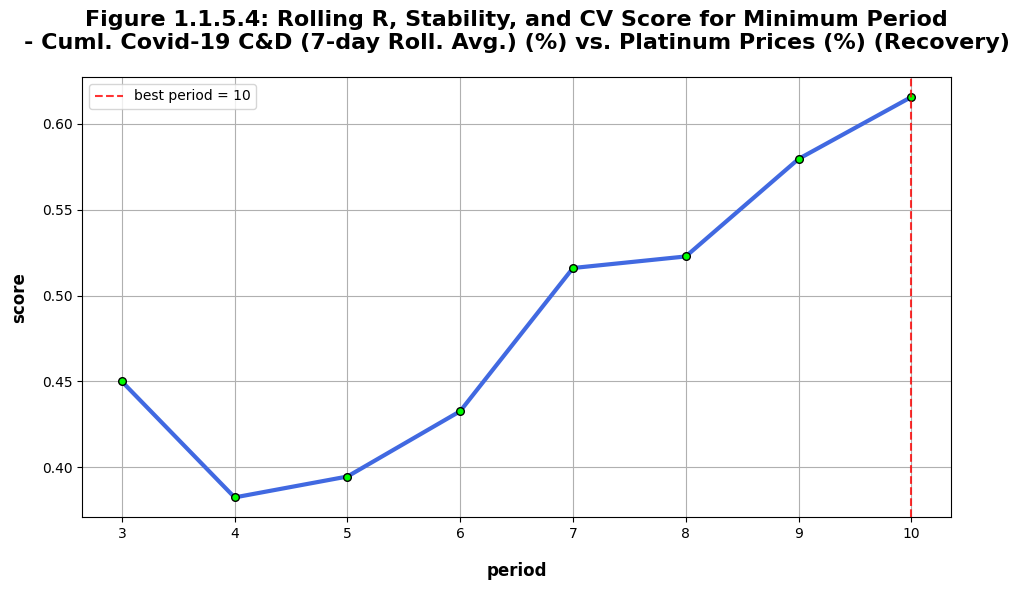

In [76]:
title = 'Figure 1.1.5.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y3**

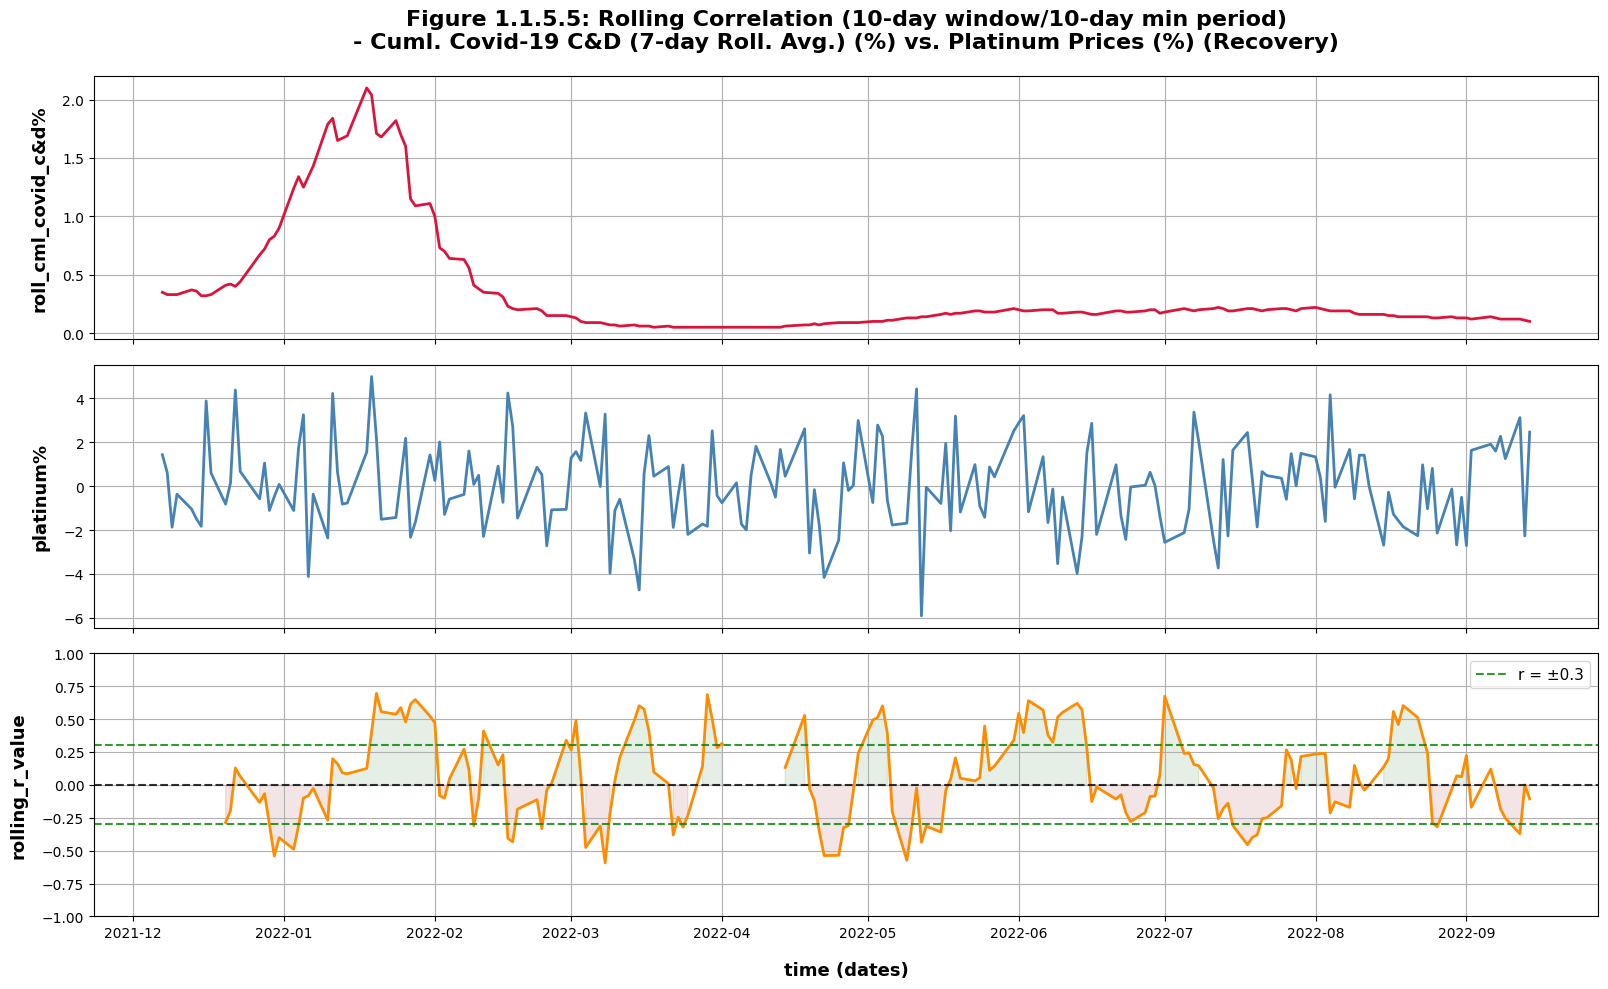

In [77]:
title \
    = f'Figure 1.1.5.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y3_series, title)

### **Lag Correlation: X vs. Y3**

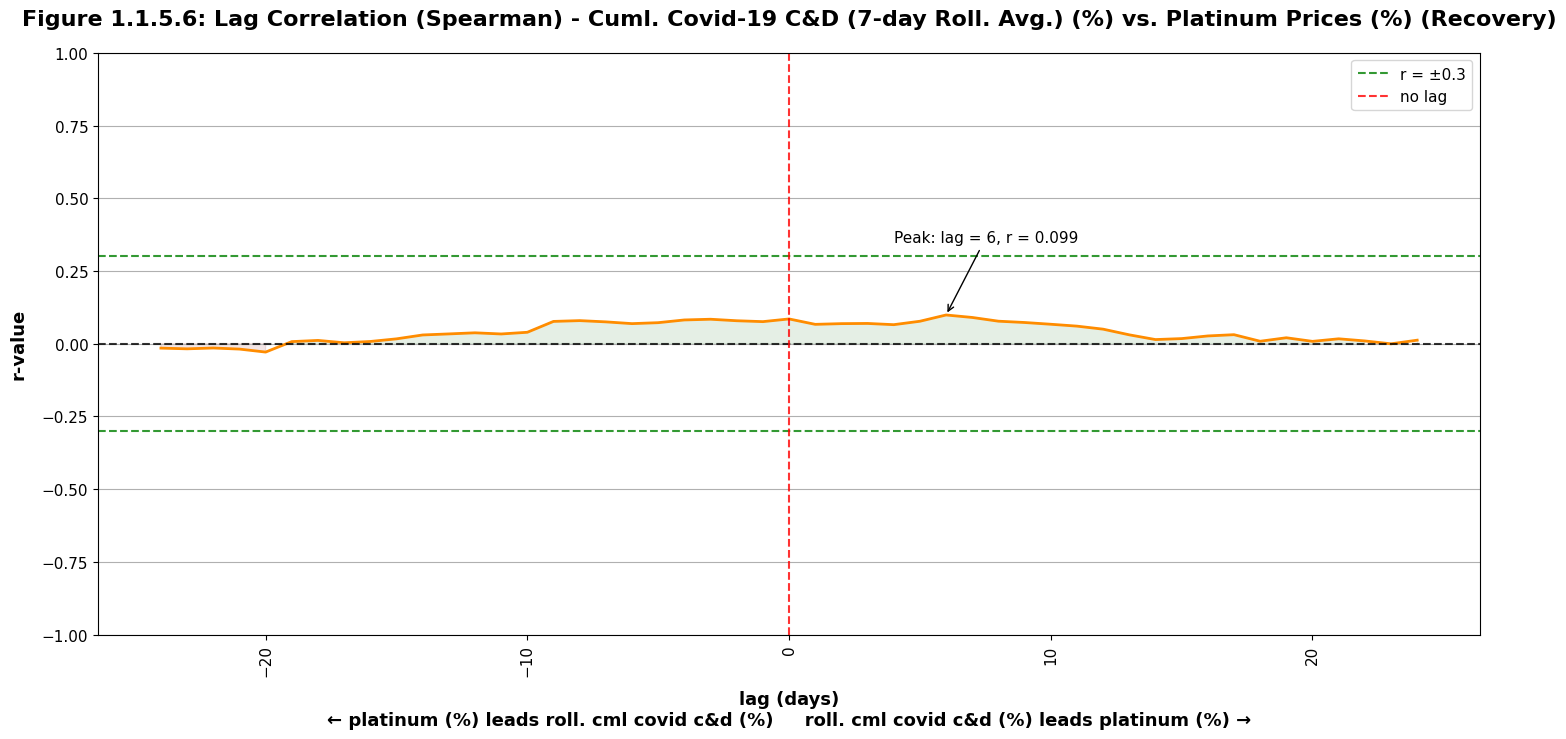

In [78]:
title = f'Figure 1.1.5.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.5.6', PRD, XCAT, YCOL)


v_lag       = int(x_y3_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y3_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y3.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y3_series, title, max_lag = max_lag)

## **1.1.6: X vs. Y4**

### **Create DataFrame X vs. Y4**

In [79]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y4.value]: y4_series})

logx.log_write_obj(comp_df)

In [80]:
title = f'Table 1.1.6.1: {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y4.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_c&d%,palladium
series,,
2021-12-07,0,0
2021-12-08,0,0
2021-12-09,0,-2
2021-12-10,0,-4
2021-12-13,0,-4
2021-12-14,0,-3
2021-12-15,0,-4
2021-12-16,0,11
2021-12-17,0,4


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y4**

In [81]:
title = 'Table 1.1.6.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y4_series, x_series)

corr_method = mathx.find_opt_corr_method(y4_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.01,-53.37,59.92,1.00,-302.95,1.00,True,1.00
2,0.02,-58.79,69.20,1.00,-302.64,0.98,True,0.99
3,0.02,-60.52,71.10,1.00,-301.02,0.85,True,0.92
4,0.02,-63.42,76.41,1.00,-299.28,0.72,True,0.86
5,0.02,-63.46,76.50,1.00,-297.31,0.56,True,0.78
6,0.02,-65.13,78.64,1.00,-295.38,0.41,True,0.71
7,0.02,-66.34,78.10,1.00,-293.41,0.26,True,0.63
8,0.02,-903.10,"1,538.51",0.77,-291.65,0.13,True,0.45
9,0.03,-473.84,467.62,0.89,-291.57,0.12,True,0.50
10,0.04,"-3,801.01","6,964.92",0.00,-290.03,0.00,True,0.00


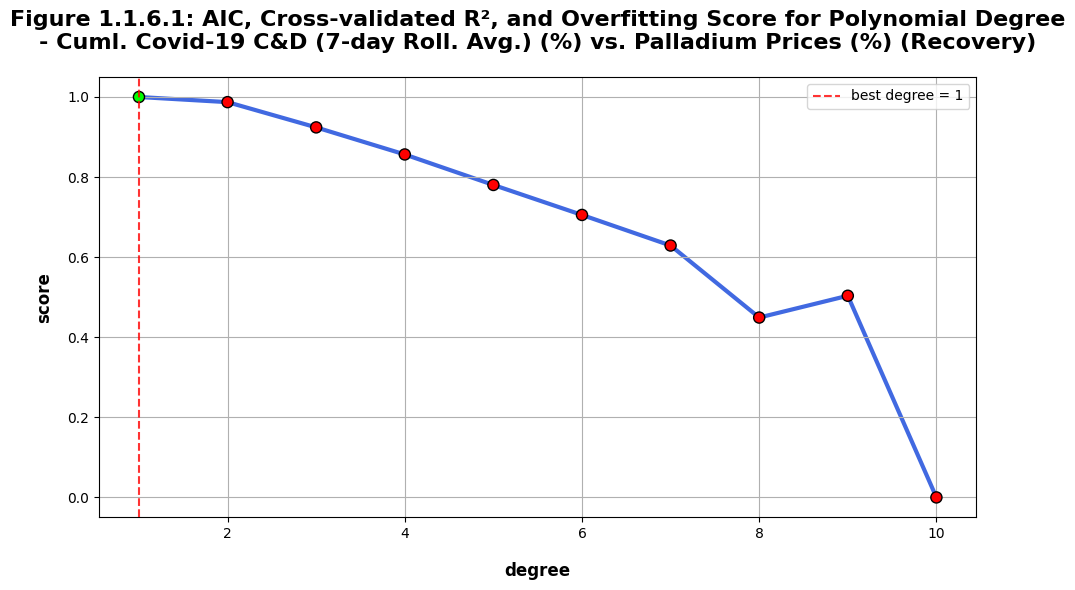

In [82]:
title = 'Figure 1.1.6.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y4**

In [83]:
title = f'Table 1.1.6.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

pandasx.rtn_fmt_tbl (comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_c&d%,palladium
roll_cml_covid_c&d%,1.00,0.07
palladium,0.07,1.00


### **Scatter Plot: X vs. Y4**

r-value (pearson):	0.100
r-value (spearman):	0.069
tau (kendall):		0.048

p-value (pearson):	0.167
p-value (spearman):	0.342
p-value (kendall):	0.329




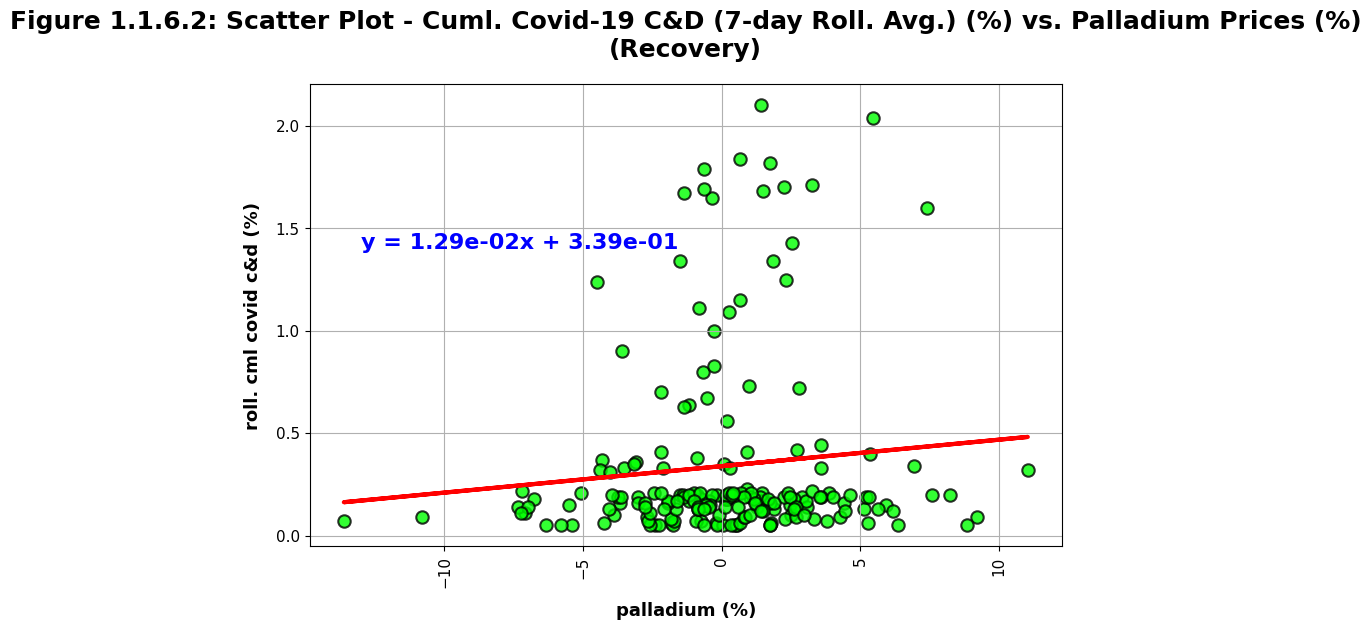

In [84]:
title = 'Figure 1.1.6.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.6.2', PRD, XCAT, YCOL)
            

matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y4.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y4_series, x_series], title)

### **The Granger Causality Test: X -> Y4**

In [85]:
title = 'Table 1.1.6.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y4.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y4_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y4_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y4_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y4.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,2.245753,0.135641,False,False,False,False,high confidence
2,1.245781,0.290093,False,False,False,False,high confidence
3,1.021570,0.384330,False,False,False,False,high confidence
4,0.862590,0.487570,False,False,False,False,high confidence
5,0.882943,0.493726,False,False,False,False,high confidence
6,0.855458,0.528976,False,False,False,False,high confidence
7,0.814813,0.576120,False,False,False,False,high confidence
8,0.993569,0.442906,False,False,False,False,high confidence


### **The Granger Causality Test: Y4 -> X**

In [86]:
title = 'Table 1.1.6.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y4.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y4_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y4.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,1.704687,0.193255,False,False,False,False,high confidence
2,0.681983,0.506866,False,False,False,False,high confidence
3,0.317097,0.813006,False,False,False,False,high confidence
4,0.244869,0.912480,False,False,False,False,high confidence
5,0.353450,0.879540,False,False,False,False,high confidence
6,0.368096,0.898423,False,False,False,False,high confidence
7,0.383212,0.911279,False,False,False,False,high confidence
8,0.392320,0.923605,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y4**

In [87]:
results_dict = mathx.fit_var_or_vecm(x_series, y4_series)

x_y4_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y4.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_C&D% VS. PALLADIUM% ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.102070, p = 0.243683).

Series 'y' is stationary (ADF = -8.779950, p = 0.000000).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 8.
AIC = 8, BIC = 8, HQIC = 8, FPE = 8.

VECM(lag = 7, rank = 1) fitted. Adjustment speeds — x: -0.000166, y: 0.885986. Error correction half-life: inf periods. x - (1.654174) * y = 0  (long-run equilibrium). Mean reversion: CONFIRMED.

IRF (VECM, 30 periods):
A one-SD shock to x produces a positive net response in y.
Peak x→y effect at lag 11 (magnitude: 4.442344).
Cumulative x→y response: 50.121286.

FEVD (VECM, horizon = 31):
x shocks explain 2.969850% of y's forecast variance (minimal influence).
y's own shocks explain 97.030150% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y4**

In [88]:
title = 'Table 1.1.6.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y4.value]} {PRD}\n')

except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y4.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,1.028660,0.284409,-0.000347,0.041364
2,1.166097,-0.180320,-0.000065,-0.016880
3,1.343049,-3.875767,-0.000520,-0.156323
4,1.628137,-0.907829,-0.000600,0.022769
5,2.216064,-1.981304,-0.001087,-0.098569
6,2.459092,4.259616,0.000376,-0.051456
7,2.228708,3.203717,0.000059,-0.013713
8,2.522868,-0.479445,0.000061,-0.155097


### **Forecast Error Variance Decomposition (FEVD): X vs. Y4**

In [89]:
if irf_bool:
    
    title = 'Table 1.1.6.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

else:

    title = 'Table 1.1.6.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.001176,0.998824,1.000000,0.000000
1,0.001271,0.998729,0.999773,0.000227
2,0.001291,0.998709,0.999850,0.000150
3,0.003229,0.996771,0.999778,0.000222
4,0.003295,0.996705,0.999766,0.000234
5,0.003613,0.996387,0.999609,0.000391
6,0.007786,0.992214,0.999429,0.000571
7,0.009613,0.990387,0.999361,0.000639
8,0.009405,0.990595,0.999286,0.000714


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y4**

In [90]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y4_series, method = corr_method)

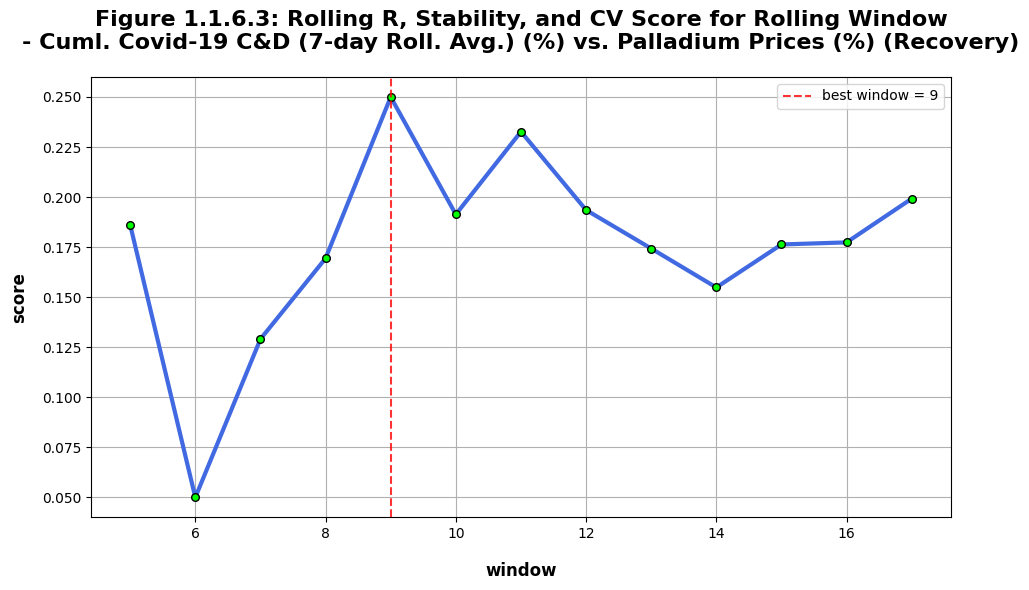

In [91]:
title = 'Figure 1.1.6.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y4**

In [92]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y4_series, best_w, method = corr_method)

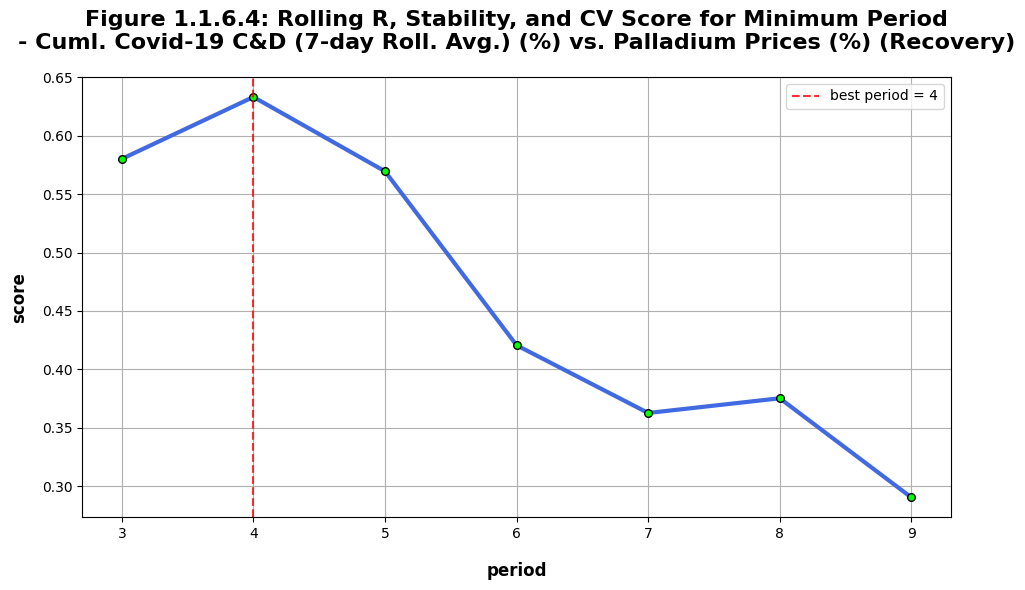

In [93]:
title = 'Figure 1.1.6.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y4**

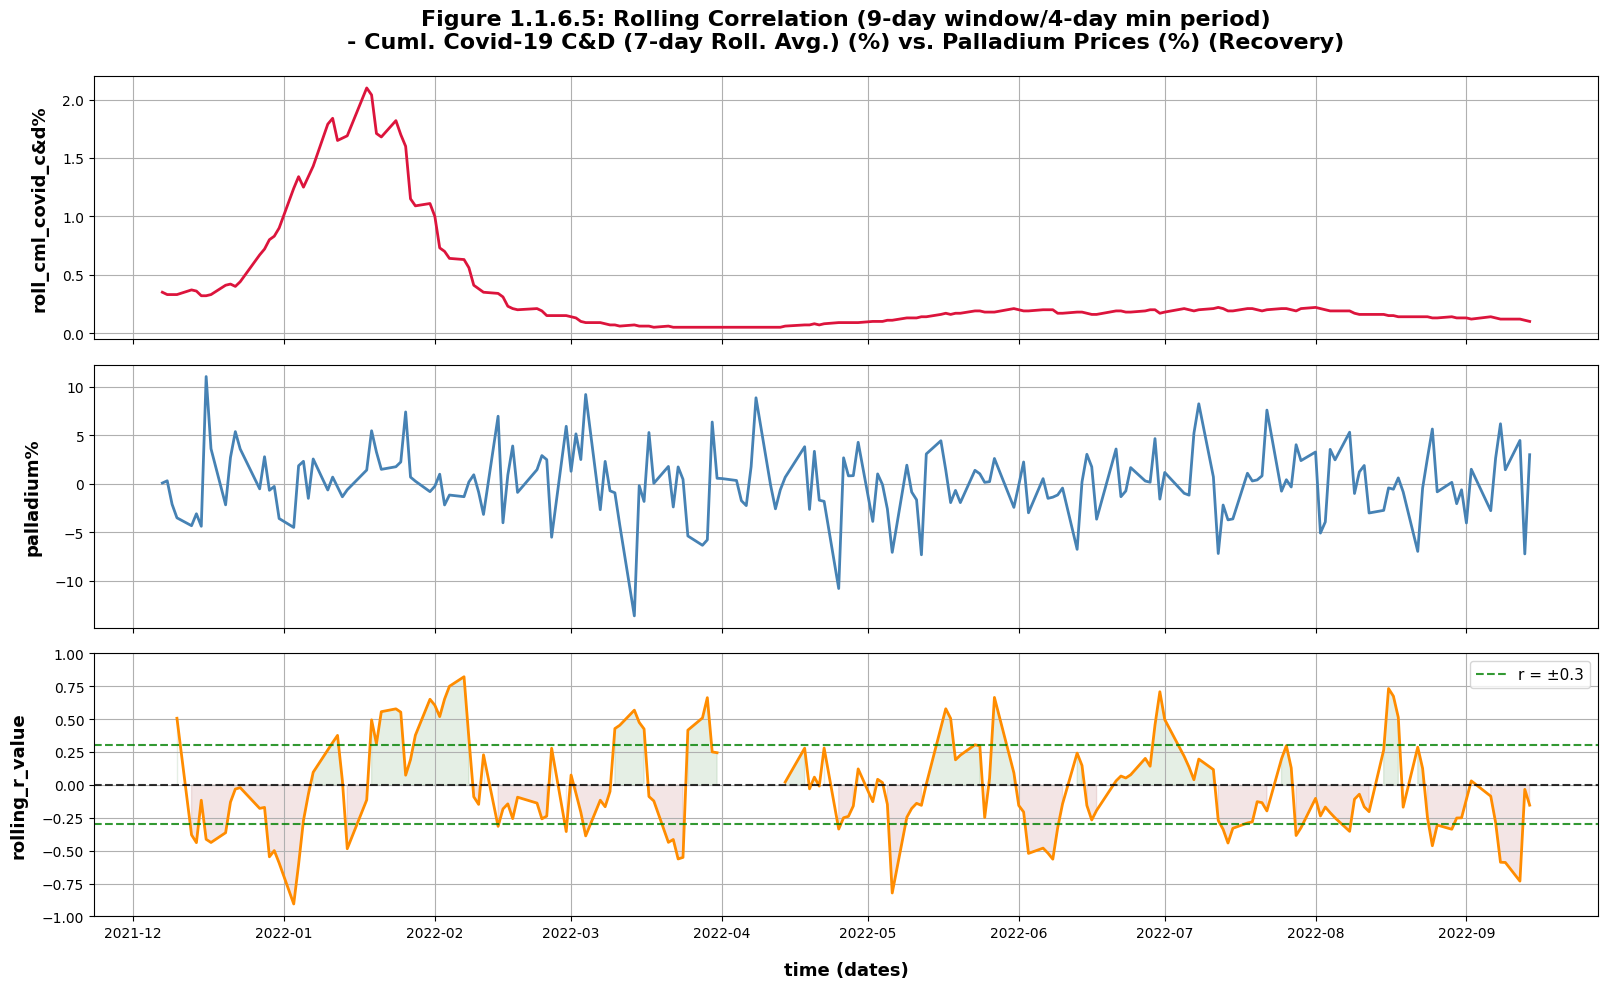

In [94]:
title \
    = f'Figure 1.1.6.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y4_series, title)

### **Lag Correlation: X vs. Y4**

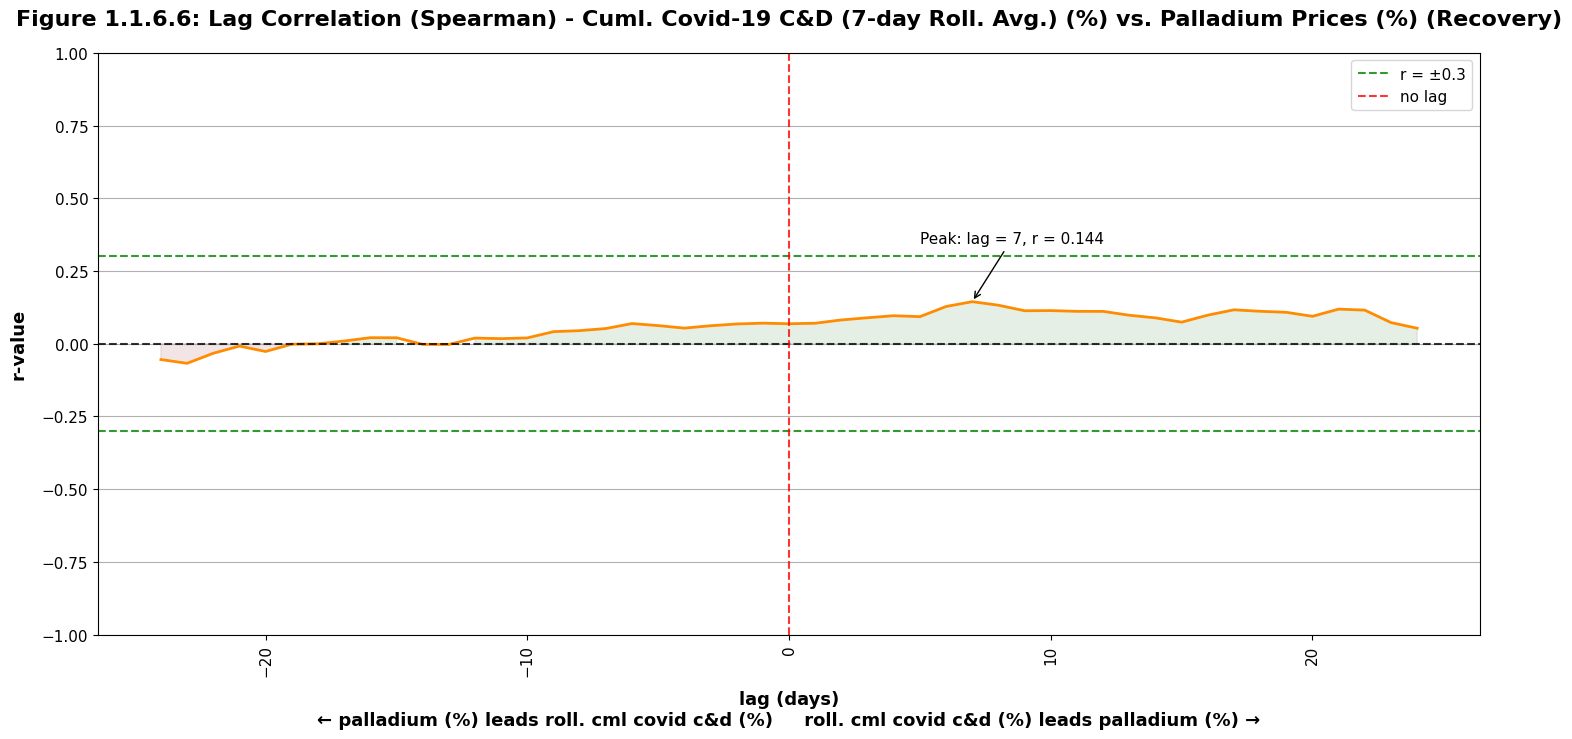

In [95]:
title = f'Figure 1.1.6.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.6.6', PRD, XCAT, YCOL)


v_lag       = int(x_y4_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y4_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y4.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y4_series, title, max_lag = max_lag)

## **1.1.7: X vs. Y5**

### **Create DataFrame X vs. Y5**

In [96]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y5.value]: y5_series})

logx.log_write_obj(comp_df)

In [97]:
title = f'Table 1.1.7.1: {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y5.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_c&d%,copper
series,,
2021-12-07,0,1
2021-12-08,0,-0
2021-12-09,0,-2
2021-12-10,0,1
2021-12-13,0,1
2021-12-14,0,-2
2021-12-15,0,-2
2021-12-16,0,4
2021-12-17,0,0


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y5**

In [98]:
title = 'Table 1.1.7.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y5_series, x_series)

corr_method = mathx.find_opt_corr_method(y5_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.00,-51.24,57.15,1.00,-301.56,0.96,True,0.98
2,0.00,-52.92,58.10,1.00,-299.57,0.71,True,0.86
3,0.02,-64.84,78.72,1.00,-301.88,1.00,True,1.00
4,0.03,-97.23,109.46,1.00,-300.18,0.79,True,0.89
5,0.03,-182.30,222.31,1.00,-298.56,0.59,True,0.79
6,0.03,-513.61,792.19,1.00,-296.83,0.38,True,0.69
7,0.03,"-2,217.11","4,150.73",0.99,-295.40,0.20,True,0.59
8,0.04,"-4,094.09","7,970.44",0.98,-295.56,0.22,True,0.60
9,0.04,"-209,556.46","418,839.85",0.00,-293.79,0.00,True,0.00
10,0.06,"-7,059.60","14,003.41",0.97,-294.82,0.13,True,0.55


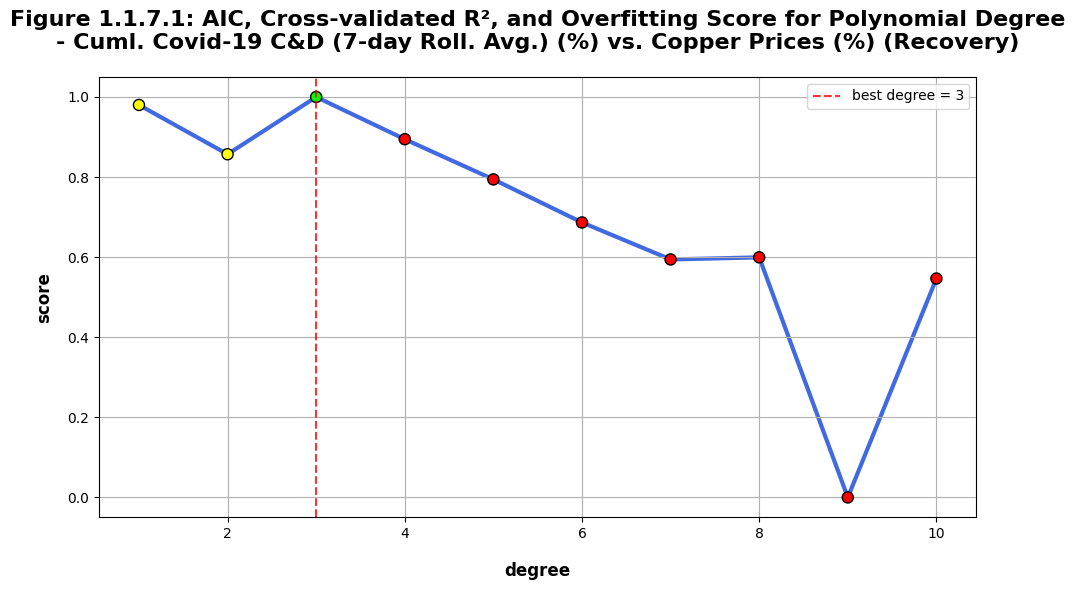

In [99]:
title = 'Figure 1.1.7.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y5**

In [100]:
title = f'Table 1.1.7.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_c&d%,copper
roll_cml_covid_c&d%,1.00,0.11
copper,0.11,1.00


### **Scatter Plot: X vs. Y5**

r-value (pearson):	0.053
r-value (spearman):	0.111
tau (kendall):		0.076

p-value (pearson):	0.466
p-value (spearman):	0.122
p-value (kendall):	0.121




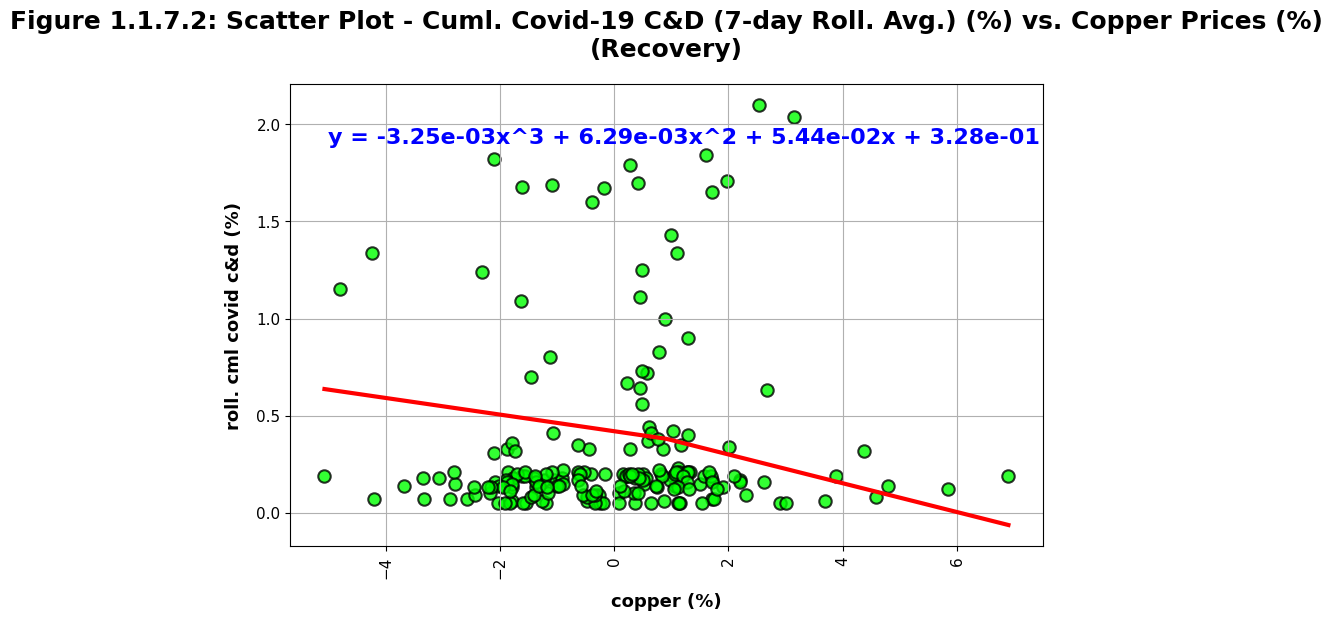

In [101]:
title = 'Figure 1.1.7.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.7.2', PRD, XCAT, YCOL)
            

matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y5.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y5_series, x_series], title)

### **The Granger Causality Test: X -> Y5**

In [102]:
title = 'Table 1.1.7.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y5.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y5_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y5_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y5_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y5.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.507201,0.477227,False,False,False,False,high confidence
2,2.986080,0.052898,False,True,True,False,non-normal residuals or insufficient sample size
3,2.257761,0.083210,False,False,False,False,high confidence
4,3.365650,0.011003,True,True,True,True,high confidence


### **The Granger Causality Test: Y5 -> X**

In [103]:
title = 'Table 1.1.7.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y5.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y5_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y5.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.706113,0.401793,False,False,False,False,high confidence
2,0.495913,0.609813,False,False,False,False,high confidence
3,0.664503,0.574868,False,False,False,False,high confidence
4,1.434763,0.224272,False,False,False,False,high confidence
5,1.135650,0.343222,False,False,False,False,high confidence
6,0.783520,0.583907,False,False,False,False,high confidence
7,0.923012,0.490061,False,False,False,False,high confidence
8,1.166748,0.322043,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y5**

In [104]:
results_dict = mathx.fit_var_or_vecm(x_series, y5_series)

x_y5_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y5.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_C&D% VS. COPPER% ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.102070, p = 0.243683).

Series 'y' is stationary (ADF = -14.388596, p = 0.000000).

Trace rank = 2, max-eigenvalue rank=0 — using trace result. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 8.
AIC = 12, BIC = 8, HQIC = 8, FPE = 12.

VECM(lag = 7, rank = 1) fitted. Adjustment speeds — x: 0.000257, y: 0.052435. Error correction half-life: inf periods. x - (18.100914) * y = 0  (long-run equilibrium). Mean reversion: NOT CONFIRMED — check alpha signs.

IRF (VECM, 30 periods):
A one-SD shock to x produces a positive net response in y.
Peak x→y effect at lag 2 (magnitude: 5.024129).
Cumulative x→y response: 5.402338.

FEVD (VECM, horizon = 31):
x shocks explain 7.091675% of y's forecast variance (moderate influence).
y's own shocks explain 92.908325% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y5**

In [105]:
title = 'Table 1.1.7.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y4.value]} {PRD}\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y5.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,1.033951,4.114145,0.000742,-0.035422
2,1.172093,5.024129,0.002739,0.114040
3,1.346741,-3.160029,0.001628,0.086506
4,1.654108,1.163526,0.000067,-0.037905
5,2.237358,1.831768,-0.002315,0.006992
6,2.473575,1.323966,0.001126,-0.059194
7,2.241482,-0.139382,-0.000652,0.056356
8,2.548047,-2.471550,-0.004408,-0.068226


### **Forecast Error Variance Decomposition (FEVD): X vs. Y5**

In [106]:
if irf_bool:
    
    title = 'Table 1.1.7.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

else:

    title = 'Table 1.1.7.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.000204,0.999796,1.000000,0.000000
1,0.018051,0.981949,0.999183,0.000817
2,0.037453,0.962547,0.994348,0.005652
3,0.043298,0.956702,0.994113,0.005887
4,0.044621,0.955379,0.995667,0.004333
5,0.047028,0.952972,0.997166,0.002834
6,0.047977,0.952023,0.997106,0.002894
7,0.047970,0.952030,0.997355,0.002645
8,0.050521,0.949479,0.997731,0.002269


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y5**

In [107]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y5_series, method = corr_method)

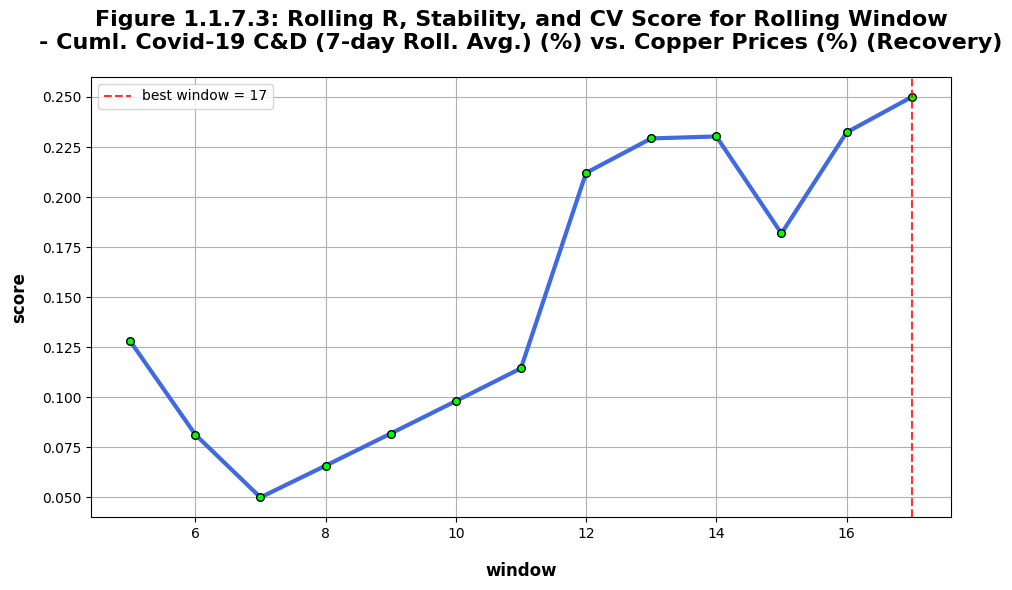

In [108]:
title = 'Figure 1.1.7.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y5**

In [109]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y5_series, best_w, method = corr_method)

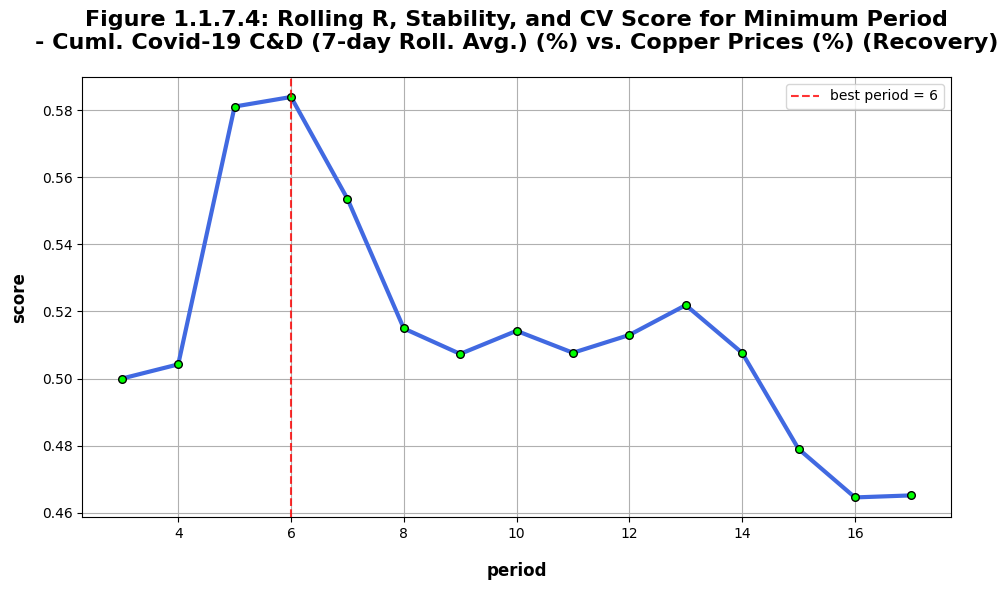

In [110]:
title = 'Figure 1.1.7.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y5**

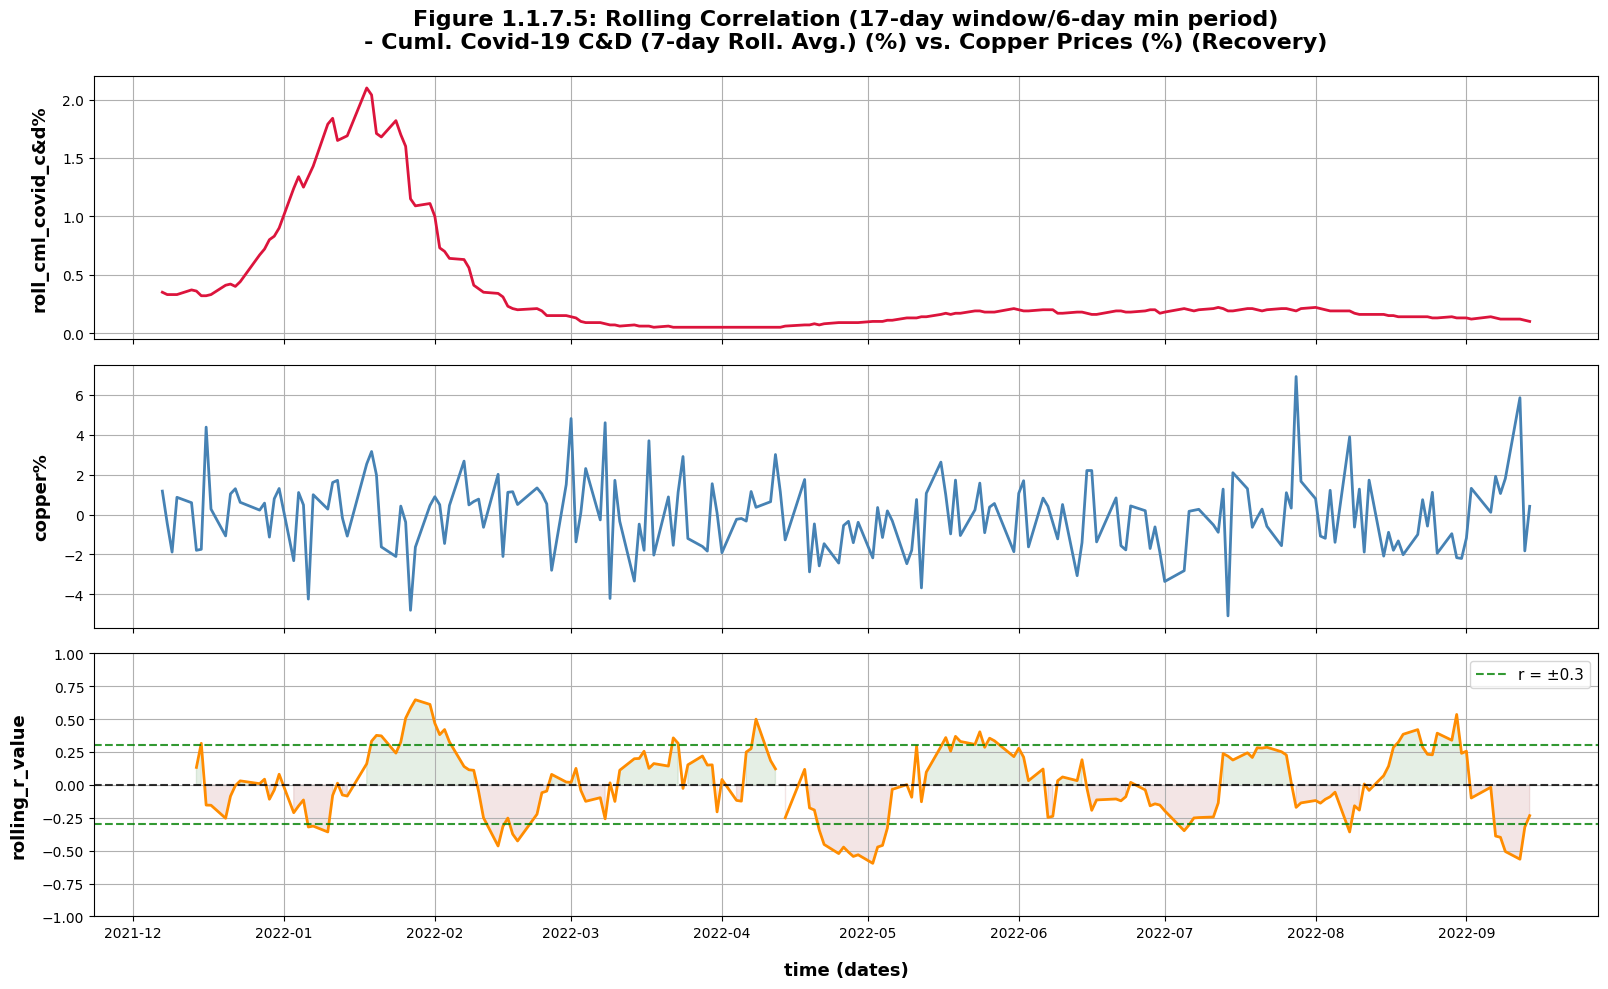

In [111]:
title \
    = f'Figure 1.1.7.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y5_series, title)

### **Lag Correlation: X vs. Y5**

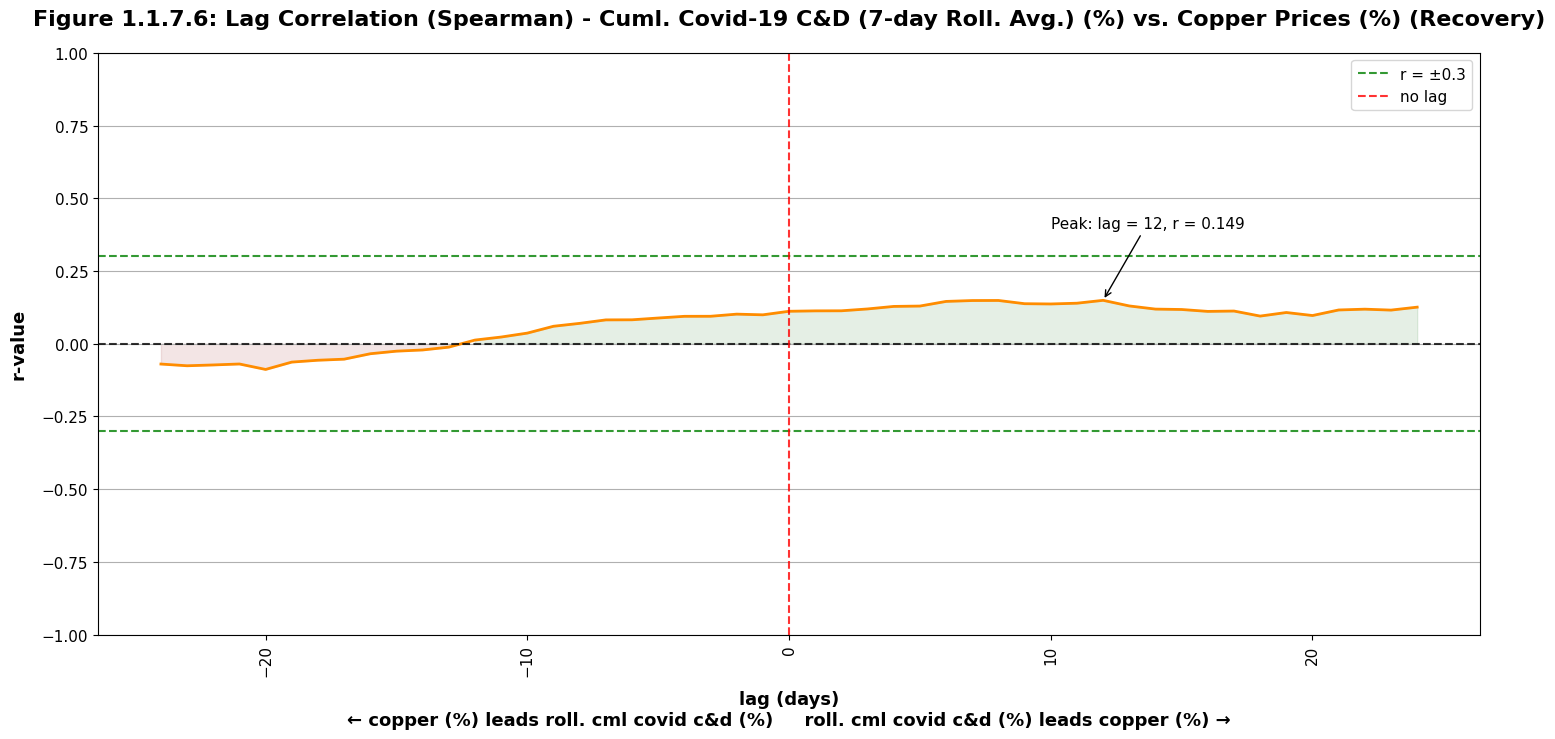

In [112]:
title = f'Figure 1.1.7.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.7.6', PRD, XCAT, YCOL)


v_lag       = int(x_y5_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y5_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y5.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y5_series, title, max_lag = max_lag)

## **1.1.8: Summary Results: X vs. Y**

### **Assemble Series Dictionaries: X vs. Y**

In [113]:
if YPCT:

    ttl_dict \
        = {XCAT:                   x_series,
           YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

    comp_dict \
        = {YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

else:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

    comp_dict \
        = {YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

### **Correlations: X vs. Y**

In [114]:
title = f'Table 1.1.8.1: Correlations ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.best_method_corr_matrix(pd.DataFrame(ttl_dict))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.3f}')

,roll_cml_covid_c&d%,gold%,silver%,platinum%,palladium%,copper%
series,,,,,,
roll_cml_covid_c&d%,1.000,0.081,0.111,0.085,0.069,0.111
gold%,0.081,1.000,0.792,0.604,0.489,0.792
silver%,0.111,0.792,1.000,0.656,0.520,1.000
platinum%,0.085,0.604,0.656,1.000,0.606,0.656
palladium%,0.069,0.489,0.520,0.606,1.000,0.520
copper%,0.111,0.792,1.000,0.656,0.520,1.000


### **Polynomial Degrees for Correlations Summary: X vs. Y**

In [115]:
title = 'Table 1.1.8.2: Polynomial Degrees for Correlations Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.opt_degree_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['train_r2', 'cv_r2', 'cv_r2_std'])

,best_degree,coefficients,intercept,train_r2,cv_r2,cv_r2_std,aic,linearity_adequate
series,,,,,,,,
gold%,2,"['6.48e-02', '-2.61e-02']",-3.21e-02,0.0021,-0.0963,0.1248,-28.35,False
silver%,1,['2.12e-01'],-1.24e-01,0.0028,-0.1176,0.1604,240.02,True
platinum%,1,['3.94e-01'],-1.32e-01,0.0081,-0.0347,0.0537,269.32,True
palladium%,1,['7.67e-01'],-1.19e-01,0.0099,-0.0052,0.0109,489.43,True
copper%,1,['2.12e-01'],-1.24e-01,0.0028,-0.1176,0.1604,240.02,True


### **The Engle-Granger Cointegration Test: X vs. Y**

In [116]:
title = 'Table 1.1.8.3: The Engle-Granger Cointegration Test ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.eg_coint_test_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.6f}', subset = ['p_value'])

,coint_stat,p_value,trend_desc,autolag,passes_mean_test,passes_trend_test,cointegrated
series,,,,,,,
gold%,-15.08,0.000000,no trend,AIC,True,True,True
silver%,-14.42,0.000000,no trend,AIC,True,True,True
platinum%,-13.44,0.000000,no trend,AIC,True,True,True
palladium%,-8.96,0.000000,no trend,AIC,True,True,True
copper%,-14.42,0.000000,no trend,AIC,True,True,True


### **The Granger Causality Test Summary: X vs. Y**

In [117]:
title = 'Table 1.1.8.4: The Granger Causality Test Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'


test_df = pd.DataFrame(grngr_bst_list)

test_df['series'] = list(grngr_nm_list)

test_df = test_df.set_index('series')


pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['f_p_value', 'chi2_p_value', 'lrtest_p_value', 'params_f_p_value'])

,f_statistic,chi2_statistic,lrtest_statistic,params_f_statistic,f_p_value,chi2_p_value,lrtest_p_value,params_f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
series,,,,,,,,,,,,,
roll_cml_covid_c&d% -> gold,2.25,4.62,4.56,2.25,0.1085,0.0995,0.1022,0.1085,False,False,False,False,high confidence
gold -> roll_cml_covid_c&d%,1.10,5.85,5.76,1.10,0.3608,0.3208,0.3298,0.3608,False,False,False,False,high confidence
roll_cml_covid_c&d% -> silver,3.37,14.13,13.63,3.37,0.0110,0.0069,0.0086,0.0110,True,True,True,True,high confidence
silver -> roll_cml_covid_c&d%,1.43,6.02,5.93,1.43,0.2243,0.1973,0.2044,0.2243,False,False,False,False,high confidence
roll_cml_covid_c&d% -> platinum,4.50,9.23,9.02,4.50,0.0124,0.0099,0.0110,0.0124,True,True,True,True,high confidence
platinum -> roll_cml_covid_c&d%,5.07,5.15,5.08,5.07,0.0256,0.0233,0.0242,0.0256,True,True,True,True,high confidence
roll_cml_covid_c&d% -> palladium,2.25,2.28,2.27,2.25,0.1356,0.1309,0.1321,0.1356,False,False,False,False,high confidence
palladium -> roll_cml_covid_c&d%,1.70,1.73,1.72,1.70,0.1933,0.1882,0.1892,0.1933,False,False,False,False,high confidence
roll_cml_covid_c&d% -> copper,3.37,14.13,13.63,3.37,0.0110,0.0069,0.0086,0.0110,True,True,True,True,high confidence


### **VAR/VECM Analysis Summary: X vs. Y**

In [118]:
title = 'Table 1.1.8.5: VAR/VECM Analysis Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'


test_df \
    = pd.concat \
        ([x_y1_analysis_df, 
          x_y2_analysis_df,
          x_y3_analysis_df,
          x_y4_analysis_df,
          x_y5_analysis_df])

test_df['series'] = list(comp_dict)

test_df = test_df.dropna(how = 'all', axis = 1)

test_df = test_df.set_index('series')


pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['fevd_x_share_in_y', 'fevd_y_own_share']) \
    .format('{:,.6f}', subset = ['irf_peak_mag'])

,model_type,x_stationary,y_stationary,coint_rank,lag,is_stable,irf_peak_lag,irf_peak_mag,irf_sign,fevd_x_share_in_y,fevd_y_own_share,half_life
series,,,,,,,,,,,,
gold%,VECM,False,True,2,7,True,1,3.268658,positive,0.0694,0.9306,inf
silver%,VECM,False,True,2,7,False,2,5.024129,positive,0.0709,0.9291,inf
platinum%,VECM,False,True,2,7,False,1,5.317753,positive,0.0789,0.9211,inf
palladium%,VECM,False,True,2,7,True,11,4.442344,positive,0.0297,0.9703,inf
copper%,VECM,False,True,2,7,False,2,5.024129,positive,0.0709,0.9291,inf


### **Rolling Windows Summary: X vs. Y**

In [119]:
title = 'Table 1.1.8.6: Rolling Windows Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df, w_array = mathx.opt_window_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['rc_mean', 'rc_std', 'cv_mean', 'cv_std', 'ac1', 'ac1_penalty'])

,optimal_window,rc_mean,rc_std,pct_significant%,cv_mean,cv_std,is_stable,ac1,ac1_penalty,score%
series,,,,,,,,,,
gold%,14,nan,nan,3.87,nan,nan,False,nan,0.0000,25.00
silver%,17,nan,nan,6.74,nan,nan,False,nan,0.0000,25.00
platinum%,10,nan,nan,5.41,nan,nan,False,nan,0.0000,25.00
palladium%,9,nan,nan,6.99,nan,nan,False,nan,0.0000,25.00
copper%,17,nan,nan,6.74,nan,nan,False,nan,0.0000,25.00


### **Rolling Minimum Periods Summary: X vs. Y**

In [120]:
title = 'Table 1.1.8.7: Rolling Minimum Periods Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

roll_corr_df = mathx.opt_min_period_summ_df(x_series, comp_dict, w_array)

pandasx.rtn_fmt_tbl(roll_corr_df, title, hide_idx_bool = False) \
    .format('{:,.3f}', subset = ['warmup_cost', 'stability', 'convergence']) \
    .format('{:,.4f}', subset = ['rc_mean', 'rc_std', 'cv_mean', 'cv_std', 'nan_fraction'])

,min_period,window,rc_mean,rc_std,cv_mean,cv_std,nan_fraction,pct_significant%,warmup_cost,stability,convergence,score%
series,,,,,,,,,,,,
gold%,4,14,-0.0285,0.2323,0.2211,0.0706,0.0361,3.74,0.021,1.257,0.649,65.32
silver%,6,17,0.0223,0.2643,0.2415,0.0325,0.0309,6.38,0.031,1.218,0.777,58.39
platinum%,10,10,0.0610,0.3250,0.2831,0.0216,0.0876,5.65,0.052,1.182,0.815,61.55
palladium%,4,9,-0.0084,0.3452,0.2845,0.0350,0.0619,7.14,0.021,1.254,0.758,63.31
copper%,6,17,0.0223,0.2643,0.2415,0.0325,0.0309,6.38,0.031,1.218,0.777,58.39


### **Rolling Correlations: X vs. Y**

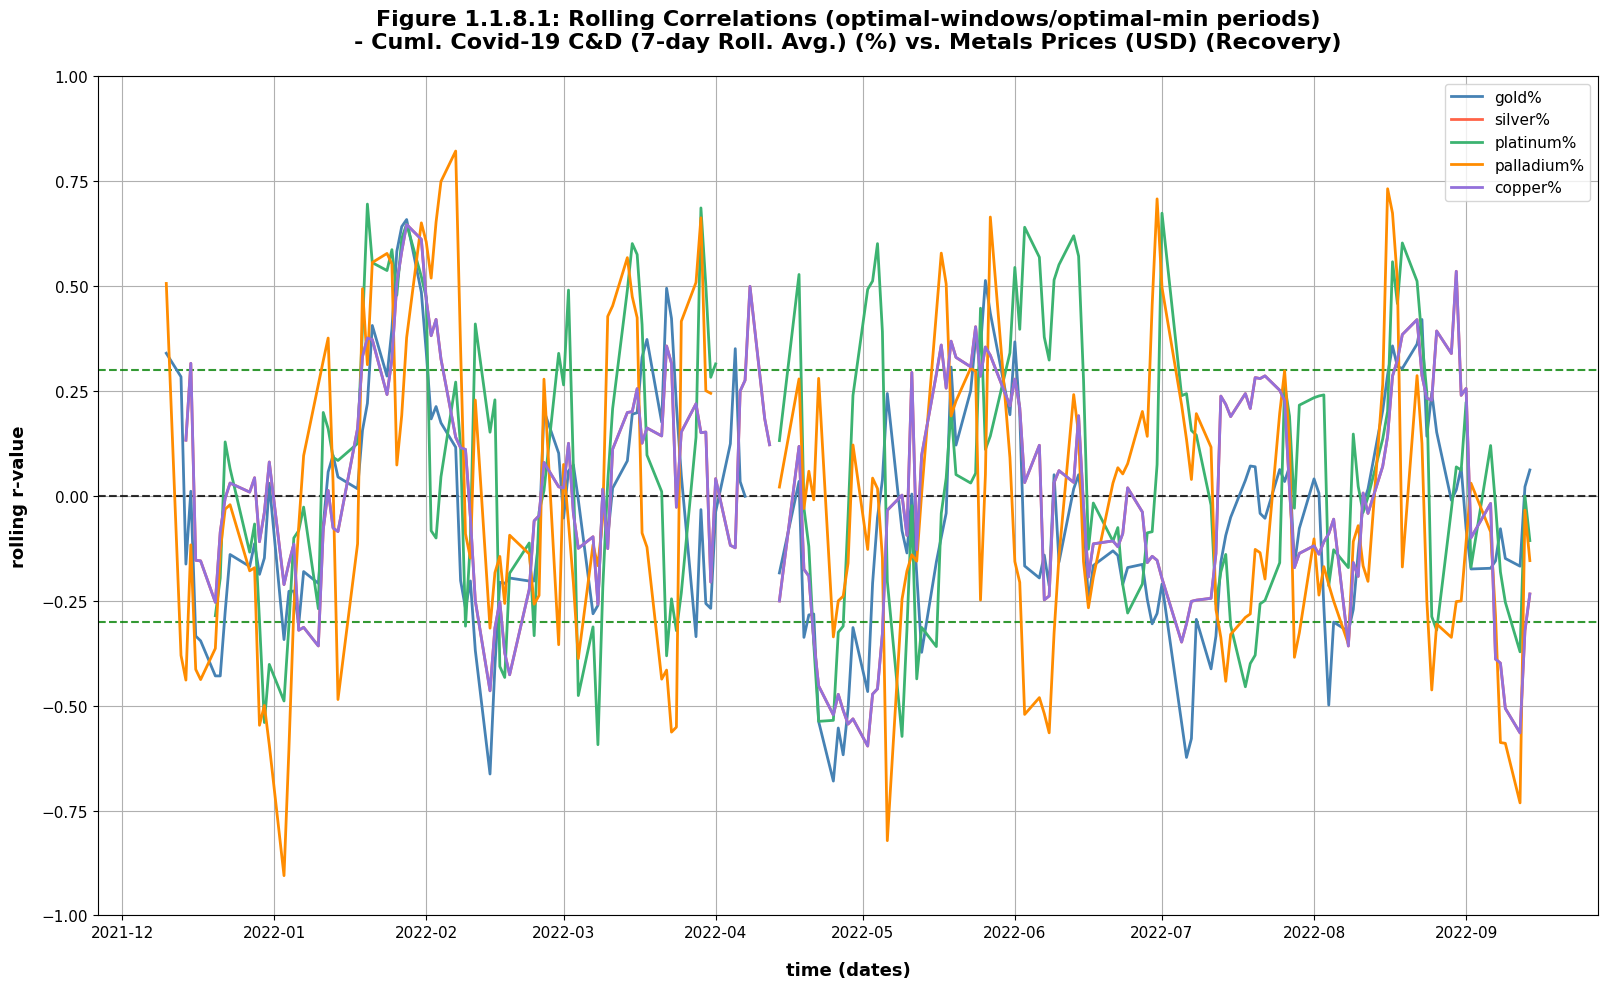

In [121]:
title = 'Figure 1.1.8.1: Rolling Correlations (optimal-windows/optimal-min periods)\n' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

matplotlibx.set_roll_corr_all_xylabels('time (dates)', 'rolling r-value')

matplotlibx.plot_all_rolling_corrs_lines(x_series, comp_dict, title, roll_corr_df)

### **Lag Correlation Summary: X vs. Y**

In [122]:
title = 'Table 1.1.8.8: Lag Correlations Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.lag_corr_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.3f}', subset = ['r_same_day', 'r_peak', 'r_improvement']) \
    .format('{:,.6f}', subset = ['p_same_day', 'raw_p_peak', 'p_peak_bonferroni'])

,r_same_day,p_same_day,significant,peak_lag,r_peak,raw_p_peak,p_peak_bonferroni,significant_peak,r_improvement
series,,,,,,,,,
platinum%,0.085,0.238307,False,177,0.606,0.009952,1.000000,False,0.521
copper%,0.111,0.121965,False,176,0.540,0.020789,1.000000,False,0.428
silver%,0.111,0.121965,False,176,0.540,0.020789,1.000000,False,0.428
palladium%,0.069,0.342479,False,-179,-0.422,0.116692,1.000000,False,0.354
gold%,0.081,0.262796,False,-173,-0.393,0.077913,1.000000,False,0.312


### **Lag Correlation Heatmap: X vs. Y**

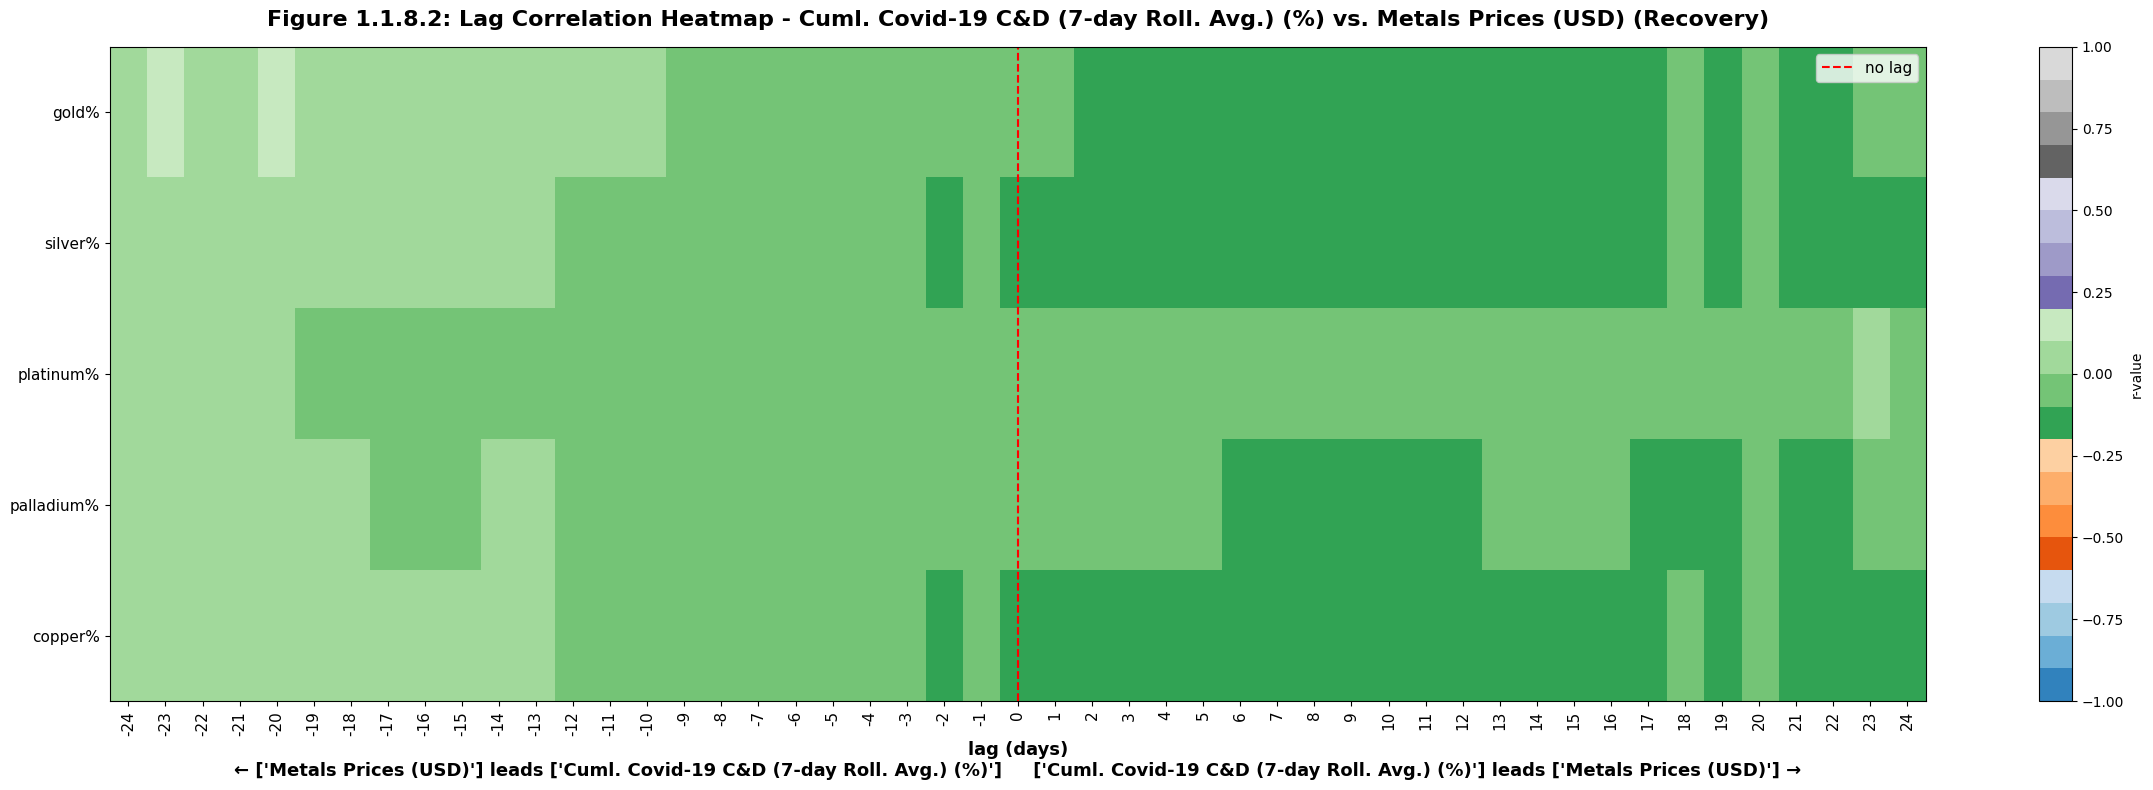

In [123]:
title = 'Figure 1.1.8.2: Lag Correlation Heatmap ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'


matplotlibx.set_lag_heat_xylabels(XTTL, YSBJ)

matplotlibx.set_lag_heat_corr_method(corr_method)


matplotlibx.plot_lag_heatmap(x_series, comp_dict, title, max_lag = max_max_lag)

In [124]:
logx.end_program()

Program execution begins at 2026/05/03 16:27:57.
Program execution ends at 2026/05/03 16:31:52.

Program execution ran for 00:03:55.

